# Macro Analysis
This section analyses the Google Merchandise Store funnel using aggregated
BigQuery exports covering Nov 2020 – Jan 2021 (4.3M events, 360k sessions).
Four customer paths are examined : conversion funnel, promo efficiency,
checkout abandonment, and search vs direct browse.
Data is loaded from local CSV exports. Session-level analysis is available
in the Micro Analysis section below.

In [ ]:
# Imports
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import pandas as pd
import seaborn as sns
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

In [127]:
# ── [CELLULE 0 — CONFIG] À placer avant tout import ──────────────────────────
from pathlib import Path

# Racine du projet — adapter si besoin, mais un seul endroit à changer
PROJECT_ROOT = Path(__file__).parent if "__file__" in dir() else Path.cwd()

DATA_DIR    = PROJECT_ROOT / "data"        # CSV exports BigQuery
OUTPUT_DIR  = PROJECT_ROOT / "outputs"    # Graphiques générés
OUTPUT_DIR.mkdir(exist_ok=True)

In [ ]:
df_promo        = pd.read_csv(DATA_DIR / "P1 promo efficiency.csv")
df_conversion   = pd.read_csv(DATA_DIR / "P2 Conversion Analysis with drop off rate.csv")
df_research_nav = pd.read_csv(DATA_DIR / "P3 Research Nav & discovery.csv")
df_dropoff_rate = pd.read_csv(DATA_DIR / "P4 Drop off rate and step.csv")

## Path 1 — Conversion funnel : how does Google Merchandise Store currently perform ?

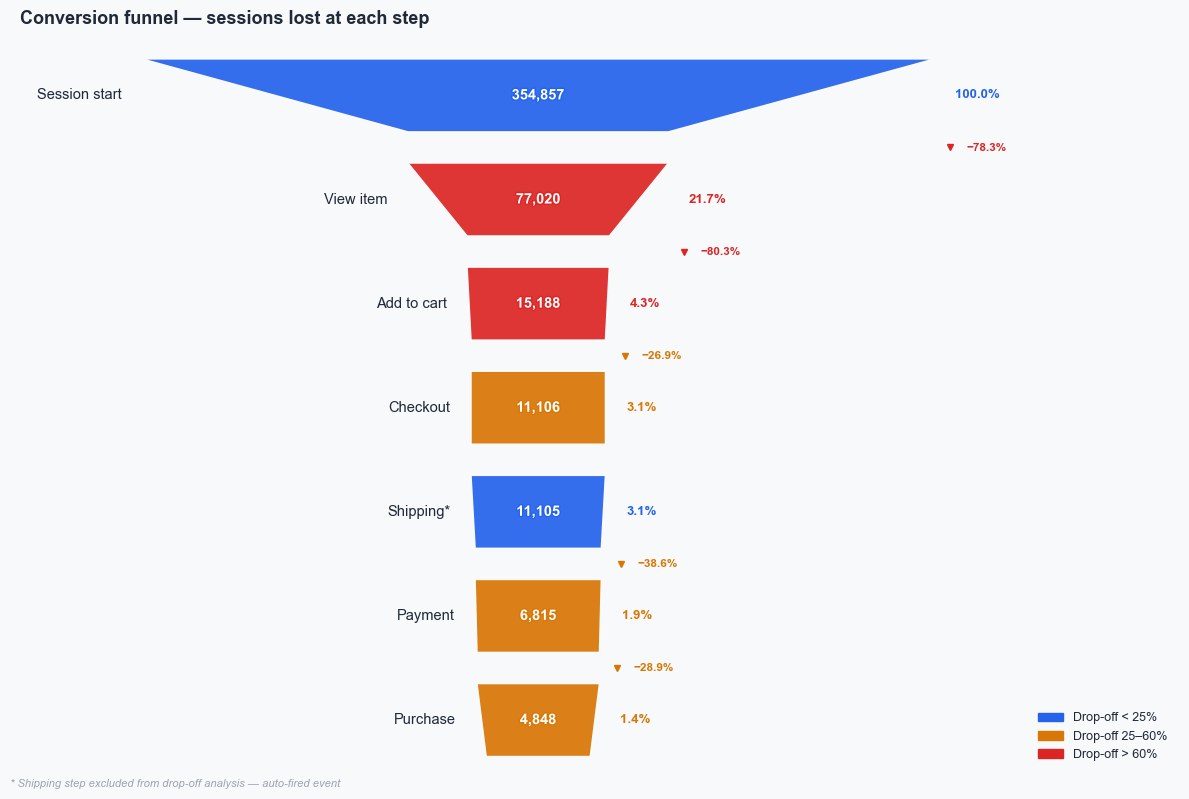

In [ ]:

funnel_labels = ['Session start', 'View item', 'Add to cart',
                 'Checkout', 'Shipping*', 'Payment', 'Purchase']
funnel_values = [354857, 77020, 15188, 11106, 11105, 6815, 4848]
drop_rates    = [None, 78.3, 80.3, 26.9, 0.0, 38.6, 28.9]

# ── Palette ───────────────────────────────────────────────────────────────────
C_BLUE  = '#2563EB'
C_AMBER = '#D97706'
C_RED   = '#DC2626'
C_BG    = '#F8F9FB'
C_TEXT  = '#1F2937'
C_MUTED = '#9CA3AF'

def bar_color(drop):
    if drop is None: return C_BLUE
    if drop >= 60:   return C_RED
    if drop >= 25:   return C_AMBER
    return C_BLUE

def drop_color(drop):
    if drop >= 60:   return C_RED
    if drop >= 25:   return C_AMBER
    return '#6B7280'

# ── Layout ────────────────────────────────────────────────────────────────────
n      = len(funnel_labels)
max_v  = funnel_values[0]

# Coordinate system : x in [0,1], y in rows (0 = top)
ROW_H  = 0.70   # height of each trapezoid
GAP    = 0.30   # gap between rows
CX     = 0.50   # horizontal centre

# Half-widths proportional to value
MAX_HW = 0.42
MIN_HW = 0.06
half_w = [MIN_HW + (MAX_HW - MIN_HW) * (v / max_v) for v in funnel_values]

# y_top[i] = top y of row i  (y increases downward in data coords,
# we'll invert the axis so row 0 is at the top of the figure)
def row_top(i):    return i * (ROW_H + GAP)
def row_bot(i):    return row_top(i) + ROW_H
def row_mid(i):    return row_top(i) + ROW_H / 2

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(C_BG)
ax.set_facecolor(C_BG)

# ── Draw trapezoids ───────────────────────────────────────────────────────────
for i in range(n):
    yt = row_top(i)
    yb = row_bot(i)
    hw_t = half_w[i]
    # Bottom edge = top edge of next step (continuous taper)
    hw_b = half_w[i + 1] if i + 1 < n else half_w[i] * 0.85

    color = bar_color(drop_rates[i])
    trap = plt.Polygon(
        [[CX - hw_t, yt], [CX + hw_t, yt],
         [CX + hw_b, yb], [CX - hw_b, yb]],
        closed=True,
        facecolor=color, edgecolor='white',
        linewidth=1.0, alpha=0.93, zorder=2,
    )
    ax.add_patch(trap)

    ym = row_mid(i)

    # Value inside bar
    ax.text(CX, ym, f'{funnel_values[i]:,}',
            ha='center', va='center',
            fontsize=10.5, fontweight='bold', color='white', zorder=3,
            path_effects=[pe.withStroke(linewidth=2, foreground=color)])

    # % of total — right of bar, aligned to right edge of THIS row
    pct = funnel_values[i] / max_v * 100
    ax.text(CX + hw_t + 0.022, ym, f'{pct:.1f}%',
            va='center', ha='left',
            fontsize=9.5, fontweight='bold', color=color, zorder=3)

    # Step label — left of bar, aligned to right edge of THIS row
    ax.text(CX - hw_t - 0.022, ym, funnel_labels[i],
            va='center', ha='right',
            fontsize=10.5, color=C_TEXT, zorder=3)

# ── Drop-off annotations (in the gap, right side, no arrows) ─────────────────
for i in range(1, n):
    drop = drop_rates[i]
    if drop is None or drop == 0:
        continue
    # Place annotation in the middle of the gap, to the right of the
    # *narrower* of the two adjacent edges (so it never overlaps a bar)
    hw_above = half_w[i - 1]   # bottom of previous row  →  wider
    hw_below = half_w[i]       # top of current row      →  narrower
    x_ref    = CX + max(hw_above, hw_below) + 0.022

    gap_mid_y = row_bot(i - 1) + GAP / 2   # vertical centre of the gap

    dc = drop_color(drop)

    # Small downward triangle marker
    ax.plot(x_ref - 0.005, gap_mid_y, marker='v',
            markersize=5, color=dc, zorder=4)

    ax.text(x_ref + 0.012, gap_mid_y, f'−{drop:.1f}%',
            va='center', ha='left',
            fontsize=8.5, fontweight='bold', color=dc, zorder=4)

# ── Axes ──────────────────────────────────────────────────────────────────────
total_h = row_bot(n - 1)
ax.set_xlim(-0.05, 1.18)
ax.set_ylim(-0.15, total_h + 0.15)
ax.invert_yaxis()
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title('Conversion funnel — sessions lost at each step',
             fontweight='bold', fontsize=13, loc='left',
             color=C_TEXT, pad=14)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=C_BLUE,  label='Drop-off < 25%'),
    mpatches.Patch(color=C_AMBER, label='Drop-off 25–60%'),
    mpatches.Patch(color=C_RED,   label='Drop-off > 60%'),
]
ax.legend(handles=legend_patches, frameon=False,
          fontsize=9, loc='lower right', labelcolor=C_TEXT)

# ── Footnote ──────────────────────────────────────────────────────────────────
fig.text(0.01, 0.005,
         '* Shipping step excluded from drop-off analysis — auto-fired event',
         fontsize=8, color=C_MUTED, style='italic')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "funnel_v3.png", dpi=150, bbox_inches="tight")
plt.show()

## Path 2 — Promotion performance : does promotion drive incremental conversion ?

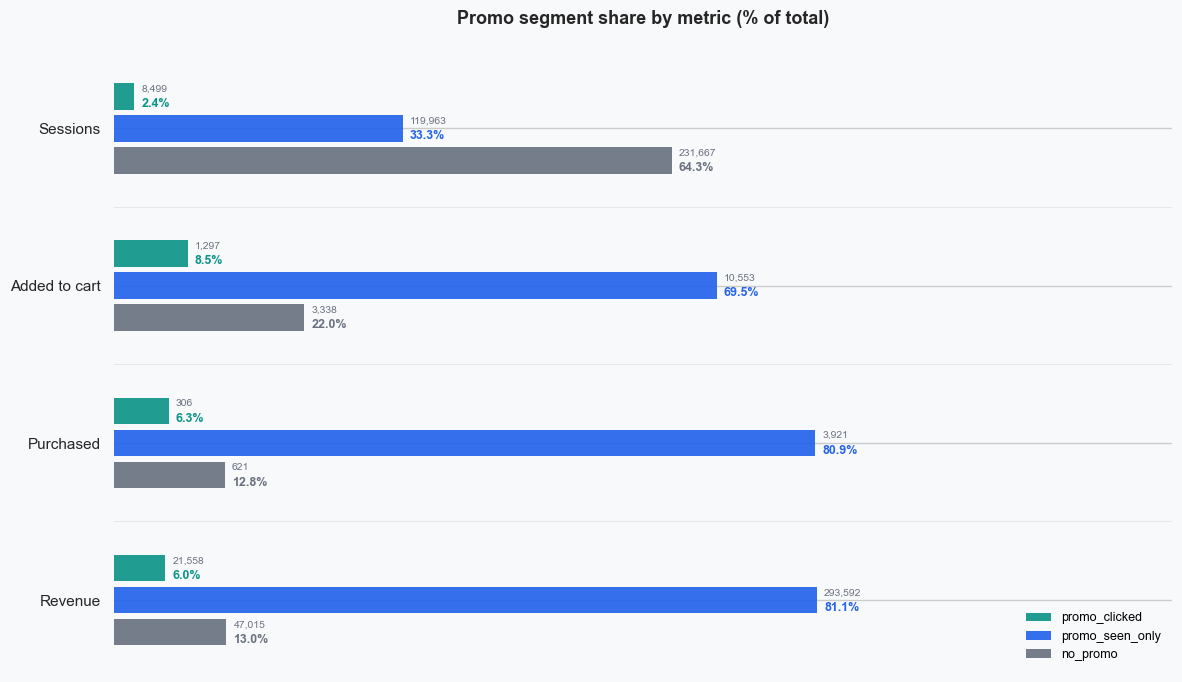

In [ ]:

metrics  = ["nb_sessions", "nb_added_cart", "nb_purchased", "total_revenue"]
labels   = ["Sessions", "Added to cart", "Purchased", "Revenue"]
segments = ["promo_clicked", "promo_seen_only", "no_promo"]
colors   = {"promo_clicked": "#0D9488", "promo_seen_only": "#2563EB", "no_promo": "#6B7280"}

# ── Layout constants ──────────────────────────────────────────────────────────
BAR_H      = 0.20   # height of a single bar
BAR_GAP    = 0.04   # gap between bars within a group
GROUP_GAP  = 0.50   # gap between metric groups
N_SEG      = len(segments)

# y-centre of each bar: group i, segment j
# group anchor at y=i*(N_SEG*BAR_H + (N_SEG-1)*BAR_GAP + GROUP_GAP)
def bar_y(i, j):
    group_h = N_SEG * BAR_H + (N_SEG - 1) * BAR_GAP
    group_top = i * (group_h + GROUP_GAP)
    return group_top + j * (BAR_H + BAR_GAP) + BAR_H / 2

# y-centre of a whole group (for ytick label)
def group_mid(i):
    ys = [bar_y(i, j) for j in range(N_SEG)]
    return (min(ys) + max(ys)) / 2

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#F8F9FB")
ax.set_facecolor("#F8F9FB")

for i, metric in enumerate(metrics):
    total = df_promo[metric].sum()
    for j, seg in enumerate(segments):
        row = df_promo[df_promo["promo_segment"] == seg]
        val = row[metric].values[0] if len(row) > 0 else 0
        pct = val / total if total > 0 else 0
        y   = bar_y(i, j)
        c   = colors[seg]

        ax.barh(y, pct, height=BAR_H,
                color=c, edgecolor="none", alpha=0.92,
                label=seg if i == 0 else "")

        # Absolute value — above the bar, same x as pct label
        ax.text(pct + 0.008, y - BAR_H * 0.28,
                f"{val:,.0f}",
                va="center", ha="left", fontsize=7.5, color="#6B7280")

        # Percentage — on the bar centre line
        ax.text(pct + 0.008, y + BAR_H * 0.28,
                f"{pct:.1%}",
                va="center", ha="left", fontsize=9,
                color=c, fontweight="bold")

# ── Axes ──────────────────────────────────────────────────────────────────────
group_mids = [group_mid(i) for i in range(len(metrics))]
ax.set_yticks(group_mids)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlim(0, 1.22)
ax.set_xticks([])

# Invert so first metric is at the top
total_h = bar_y(len(metrics) - 1, N_SEG - 1) + BAR_H / 2 + 0.2
ax.set_ylim(-0.3, total_h)
ax.invert_yaxis()

# Light separator lines between groups
for i in range(len(metrics) - 1):
    sep_y = (bar_y(i, N_SEG - 1) + bar_y(i + 1, 0)) / 2
    ax.axhline(sep_y, color="#E5E7EB", linewidth=0.8, zorder=0)

ax.set_title("Promo segment share by metric (% of total)",
             fontsize=13, fontweight="bold", pad=14, loc="center")

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(frameon=False, loc="lower right", fontsize=9,
          labelcolor="black")

# ── Footnote ──────────────────────────────────────────────────────────────────
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "promo_share.png", dpi=150, bbox_inches="tight")
plt.show()


In [134]:
df_general_metrics_promo= df_promo[["nb_sessions", "promo_segment","avg_order_value"]].copy()
df_general_metrics_promo

,nb_sessions,promo_segment,avg_order_value
0,8499,promo_clicked,70.45
1,119963,promo_seen_only,74.88
2,231667,no_promo,75.71


## Path 3 — Checkout abandonment : where do users drop off ?

In [135]:
df_dropoff_rate.head(5)

,abandonment_stage,nb_sessions,pct_of_cart_sessions
0,3_abandoned_at_cart,9226,60.7
1,5_abandoned_after_shipping,2104,13.9
2,6_abandoned_after_payment_info,1010,6.6
3,7_completed,2848,18.8


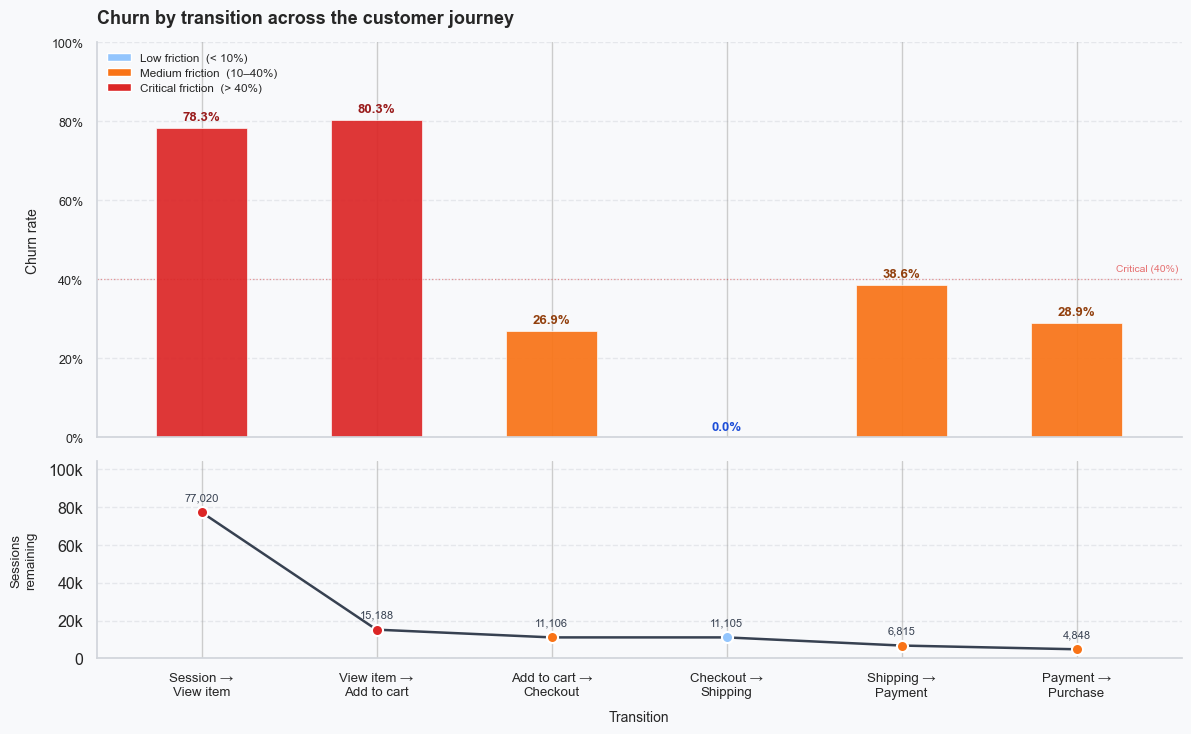

,transition,churn_pct,sessions
0,Session →\nView item,78.3,77020.0
1,View item →\nAdd to cart,80.3,15188.0
2,Add to cart →\nCheckout,26.9,11106.0
3,Checkout →\nShipping,0.0,11105.0
4,Shipping →\nPayment,38.6,6815.0
5,Payment →\nPurchase,28.9,4848.0


In [141]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

# ── Data ──────────────────────────────────────────────────────────────────────
churn_cols = [
    "drop_session_to_view", "drop_view_to_cart", "drop_cart_to_checkout",
    "drop_checkout_to_shipping", "drop_shipping_to_payment", "drop_payment_to_purchase"
]
transition_labels = [
    "Session →\nView item",
    "View item →\nAdd to cart",
    "Add to cart →\nCheckout",
    "Checkout →\nShipping",
    "Shipping →\nPayment",
    "Payment →\nPurchase"
]
funnel_cols = ["s1_session", "s2_view_item", "s3_cart", "s4_checkout",
               "s5_shipping", "s6_payment", "s7_purchase"]

churn_values = df_conversion.loc[0, churn_cols].astype(float).to_numpy()
sessions     = df_conversion.loc[0, funnel_cols].astype(float).to_numpy()

plot_df = pd.DataFrame({
    "transition": transition_labels,
    "churn_pct":  churn_values,
    "sessions":   sessions[1:],
})

n = len(transition_labels)
x = np.arange(n)

def churn_color(pct):
    if pct < 10:  return "#93C5FD"
    if pct <= 40: return "#F97316"
    return "#DC2626"

def label_color(pct):
    if pct < 10:  return "#1D4ED8"
    if pct <= 40: return "#92400E"
    return "#991B1B"

bar_colors   = [churn_color(v) for v in plot_df["churn_pct"]]
label_colors = [label_color(v) for v in plot_df["churn_pct"]]

# ── Figure : 2 subplots empilés, hauteur 2:1 ─────────────────────────────────
BG = "#F8F9FB"
fig = plt.figure(figsize=(14, 8), facecolor=BG)
gs  = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.08)

ax_top = fig.add_subplot(gs[0])   # churn bars
ax_bot = fig.add_subplot(gs[1])   # sessions line

for ax in (ax_top, ax_bot):
    ax.set_facecolor(BG)
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, alpha=0.20, linestyle="--", color="#9CA3AF")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color("#D1D5DB")
    ax.spines["left"].set_color("#D1D5DB")

# ── TOP : barres de churn ─────────────────────────────────────────────────────
BAR_W = 0.52
ax_top.bar(x, plot_df["churn_pct"],
           width=BAR_W, color=bar_colors,
           edgecolor="white", linewidth=0.5,
           alpha=0.92, zorder=2)

# Seuil critique 40%
ax_top.axhline(40, color="#DC2626", linewidth=0.9,
               linestyle=":", alpha=0.45, zorder=1)
ax_top.text(n - 0.42, 41.5, "Critical (40%)",
            ha="right", va="bottom",
            fontsize=7.5, color="#DC2626", alpha=0.65)

# Labels au-dessus des barres
for i, (v, lc) in enumerate(zip(plot_df["churn_pct"], label_colors)):
    ax_top.text(i, v + 1.2, f"{v:.1f}%",
                ha="center", va="bottom",
                fontsize=9.5, fontweight="bold", color=lc, zorder=4)

ax_top.set_ylim(0, 100)
ax_top.set_yticks([0, 20, 40, 60, 80, 100])
ax_top.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"], fontsize=9)
ax_top.set_ylabel("Churn rate", fontsize=10, labelpad=8)
ax_top.set_xticks(x)
ax_top.set_xticklabels([""] * n)   # masqués, partagés avec ax_bot

ax_top.set_title("Churn by transition across the customer journey",
                 fontsize=13, fontweight="bold", pad=14, loc="left")

# Légende dans le coin supérieur GAUCHE — loin des barres hautes
legend_patches = [
    mpatches.Patch(facecolor="#93C5FD", edgecolor="white",
                   label="Low friction  (< 10%)"),
    mpatches.Patch(facecolor="#F97316", edgecolor="white",
                   label="Medium friction  (10–40%)"),
    mpatches.Patch(facecolor="#DC2626", edgecolor="white",
                   label="Critical friction  (> 40%)"),
]
ax_top.legend(handles=legend_patches,
              frameon=False, loc="upper left",
              fontsize=8.5, labelspacing=0.4)

# ── BOTTOM : sessions restantes ───────────────────────────────────────────────
# Segments colorés selon friction de DESTINATION
for i in range(n - 1):
    ax_bot.plot([x[i], x[i+1]],
                [plot_df["sessions"].iloc[i], plot_df["sessions"].iloc[i+1]],
                color="#374151", linewidth=1.8, zorder=2,
                solid_capstyle="round")

for i, sess in enumerate(plot_df["sessions"]):
    ax_bot.plot(x[i], sess, "o",
                color=bar_colors[i], markersize=8,
                markeredgecolor="white", markeredgewidth=1.5, zorder=4)
    # Valeur : au-dessus si la prochaine est plus basse (toujours vrai ici)
    offset = plot_df["sessions"].max() * 0.07
    ax_bot.text(x[i], sess + offset, f"{sess:,.0f}",
                ha="center", va="bottom",
                fontsize=8, color="#374151", zorder=5)

sess_max = plot_df["sessions"].max()
ax_bot.set_ylim(0, sess_max * 1.35)
ax_bot.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k" if v >= 1000 else str(int(v)))
)
ax_bot.set_ylabel("Sessions\nremaining", fontsize=9.5,
                  labelpad=8, linespacing=1.4)

ax_bot.set_xticks(x)
ax_bot.set_xticklabels(transition_labels,
                       fontsize=9.5, linespacing=1.3)
ax_bot.set_xlabel("Transition", labelpad=8, fontsize=10)

plt.savefig(OUTPUT_DIR / "churn_by_transition.png", dpi=150, bbox_inches="tight")
plt.show()

plot_df

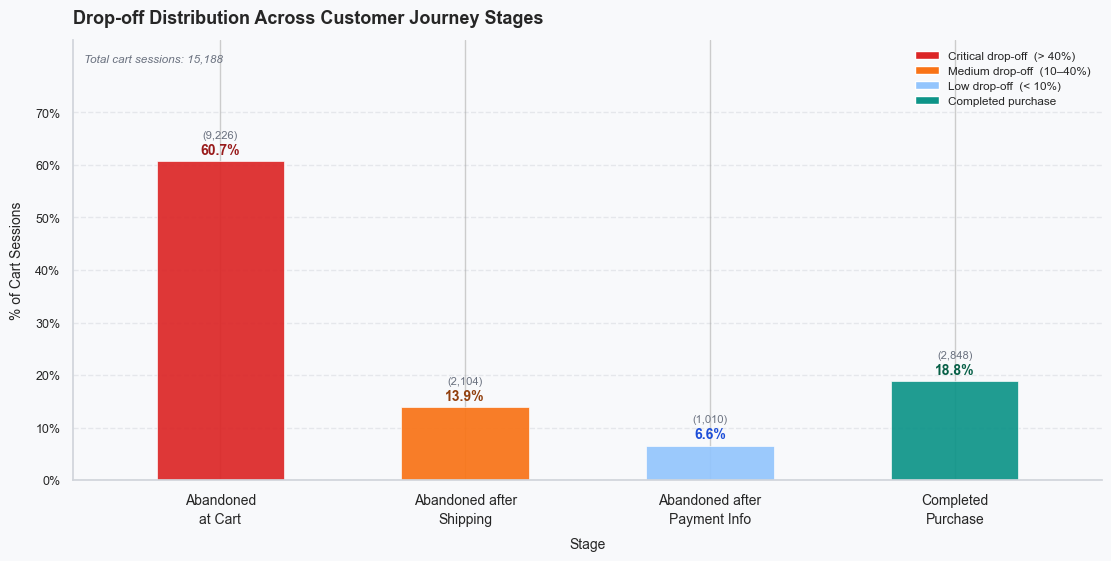

,label,churn_pct,sessions
0,Abandoned\nat Cart,60.7,9226.0
1,Abandoned after\nShipping,13.9,2104.0
2,Abandoned after\nPayment Info,6.6,1010.0
3,Completed\nPurchase,18.8,2848.0


In [143]:

# ── Data prep ─────────────────────────────────────────────────────────────────
plot_df = df_dropoff_rate.copy()
plot_df["stage_num"] = (
    plot_df["abandonment_stage"]
    .str.extract(r"^(\d+)_", expand=False)
    .astype(int)
)
plot_df = plot_df.sort_values("stage_num").reset_index(drop=True)

stage_label_map = {
    "3_abandoned_at_cart":            "Abandoned\nat Cart",
    "5_abandoned_after_shipping":     "Abandoned after\nShipping",
    "6_abandoned_after_payment_info": "Abandoned after\nPayment Info",
    "7_completed":                    "Completed\nPurchase",
}
plot_df["label"]     = plot_df["abandonment_stage"].map(stage_label_map).fillna(plot_df["abandonment_stage"])
plot_df["churn_pct"] = plot_df["pct_of_cart_sessions"].astype(float)
plot_df["sessions"]  = plot_df["nb_sessions"].astype(float)

# ── Colors ────────────────────────────────────────────────────────────────────
def stage_color(row):
    if "completed" in row["abandonment_stage"]: return "#0D9488"
    if row["churn_pct"] > 40:                   return "#DC2626"
    if row["churn_pct"] >= 10:                  return "#F97316"
    return "#93C5FD"

def label_color(row):
    if "completed" in row["abandonment_stage"]: return "#065F46"
    if row["churn_pct"] > 40:                   return "#991B1B"
    if row["churn_pct"] >= 10:                  return "#92400E"
    return "#1D4ED8"

bar_colors   = [stage_color(row) for _, row in plot_df.iterrows()]
lbl_colors   = [label_color(row) for _, row in plot_df.iterrows()]

n = len(plot_df)
x = np.arange(n)

# ── Figure ────────────────────────────────────────────────────────────────────
BG = "#F8F9FB"
fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

BAR_W = 0.52
ax.bar(x, plot_df["churn_pct"],
       width=BAR_W, color=bar_colors,
       edgecolor="white", linewidth=0.5,
       alpha=0.92, zorder=2)

# ── Label : % en gras + valeur absolue en dessous, même couleur ──────────────
for i, (row, lc) in enumerate(zip(plot_df.itertuples(), lbl_colors)):
    # Pourcentage — au-dessus de la barre
    ax.text(i, row.churn_pct + 0.8,
            f"{row.churn_pct:.1f}%",
            ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=lc, zorder=4)
    # Valeur absolue — juste en dessous du %
    ax.text(i, row.churn_pct + 0.8 + 3.2,
            f"({int(row.sessions):,})",
            ha="center", va="bottom",
            fontsize=8, color="#6B7280", zorder=4)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(-0.6, n - 0.4)
ax.set_ylim(0, plot_df["churn_pct"].max() * 1.38)
ax.set_yticks(range(0, 80, 10))
ax.set_yticklabels([f"{v}%" for v in range(0, 80, 10)], fontsize=9)
ax.set_ylabel("% of Cart Sessions", fontsize=10, labelpad=8)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], fontsize=10, linespacing=1.4)
ax.set_xlabel("Stage", labelpad=8, fontsize=10)
ax.set_axisbelow(True)
ax.yaxis.grid(True, alpha=0.20, linestyle="--", color="#9CA3AF")

# Spine styling
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
for sp in ["bottom", "left"]:
    ax.spines[sp].set_color("#D1D5DB")

ax.set_title("Drop-off Distribution Across Customer Journey Stages",
             fontsize=13, fontweight="bold", pad=12, loc="left")

# ── Total sessions annotation (haut gauche) ───────────────────────────────────
total = int(plot_df["sessions"].sum())
ax.text(0.01, 0.97,
        f"Total cart sessions: {total:,}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=8.5, color="#6B7280",
        style="italic")

# ── Légende ───────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor="#DC2626", edgecolor="white",
                   label="Critical drop-off  (> 40%)"),
    mpatches.Patch(facecolor="#F97316", edgecolor="white",
                   label="Medium drop-off  (10–40%)"),
    mpatches.Patch(facecolor="#93C5FD", edgecolor="white",
                   label="Low drop-off  (< 10%)"),
    mpatches.Patch(facecolor="#0D9488", edgecolor="white",
                   label="Completed purchase"),
]
ax.legend(handles=legend_patches,
          frameon=False, loc="upper right",
          fontsize=8.5, labelspacing=0.4)

sns.despine(ax=ax, bottom=False)

plt.savefig(OUTPUT_DIR / "dropoff_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

plot_df[["label", "churn_pct", "sessions"]]

## Path 4 — Navigation analysis

In [144]:
df_research_nav.head(5)

,path_type,nb_sessions,nb_viewed_item,nb_added_cart,nb_purchased,conversion_rate_pct,view_to_cart_rate,avg_minutes_to_purchase
0,via_search,15719,7924,2361,651,4.14,29.80,13.0
1,direct_browse,344410,69096,12827,4197,1.22,18.56,NaN


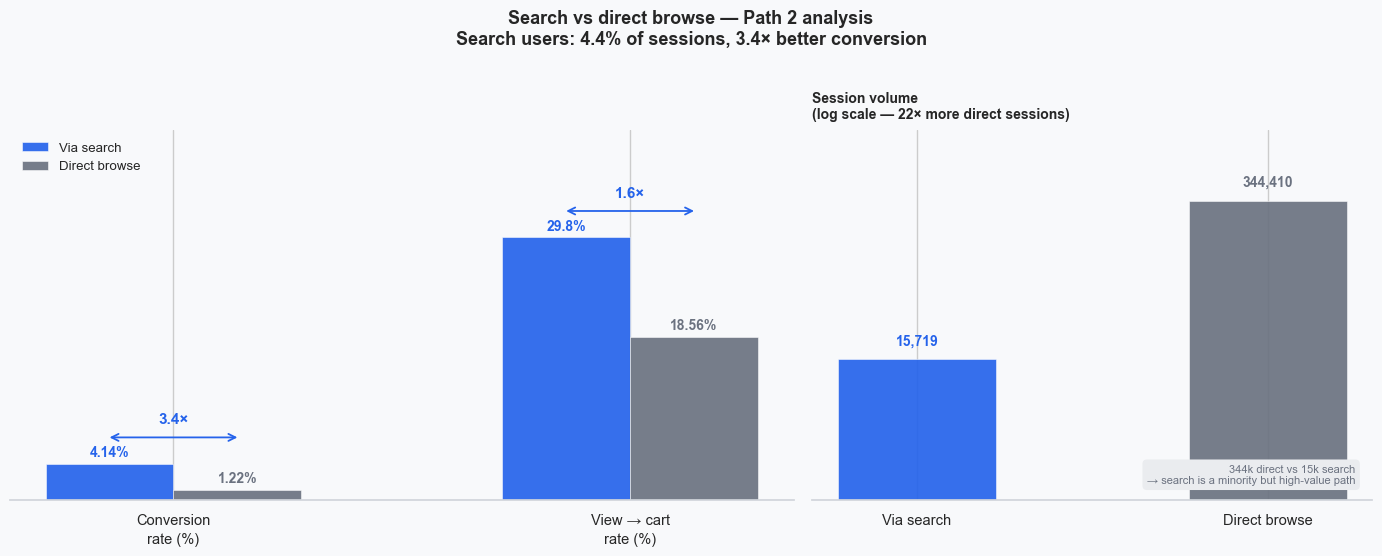

In [145]:
BG = "#F8F9FB"
C_SEARCH = "#2563EB"
C_BROWSE = "#6B7280"

# ── Data ──────────────────────────────────────────────────────────────────────
metrics     = ["Conversion\nrate (%)", "View → cart\nrate (%)"]
search_vals = [4.14, 29.8]
browse_vals = [1.22, 18.56]
multipliers = ["3.4×", "1.6×"]
sessions    = [15_719, 344_410]
seg_labels  = ["Via search", "Direct browse"]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5),
                                gridspec_kw={"width_ratios": [1.4, 1]})
fig.patch.set_facecolor(BG)
for ax in (ax1, ax2):
    ax.set_facecolor(BG)

fig.suptitle(
    "Search vs direct browse — Path 2 analysis\n"
    "Search users: 4.4% of sessions, 3.4× better conversion",
    fontsize=13, fontweight="bold", y=1.01
)

# ── Panel 1 : taux côte à côte ────────────────────────────────────────────────
x = np.arange(len(metrics))
W = 0.28

b1 = ax1.bar(x - W / 2, search_vals, width=W,
             color=C_SEARCH, edgecolor="white", linewidth=0.4,
             alpha=0.92, zorder=2, label="Via search")
b2 = ax1.bar(x + W / 2, browse_vals, width=W,
             color=C_BROWSE, edgecolor="white", linewidth=0.4,
             alpha=0.92, zorder=2, label="Direct browse")

# Labels valeurs
for bar, val, color in zip(list(b1) + list(b2),
                            search_vals + browse_vals,
                            [C_SEARCH] * 2 + [C_BROWSE] * 2):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f"{val}%",
             ha="center", va="bottom",
             fontsize=10, fontweight="bold", color=color, zorder=4)

# Multiplicateurs — positionnés au-dessus de la barre la plus haute
for i, mult in enumerate(multipliers):
    y_top   = max(search_vals[i], browse_vals[i])
    y_arrow = y_top + 3.0     # ligne de la flèche
    y_text  = y_arrow + 1.2   # texte au-dessus

    # Flèche bidirectionnelle entre les centres des deux barres
    ax1.annotate(
        "", xy=(x[i] + W / 2, y_arrow),
        xytext=(x[i] - W / 2, y_arrow),
        arrowprops=dict(arrowstyle="<->",
                        color=C_SEARCH, lw=1.3,
                        shrinkA=0, shrinkB=0),
        zorder=4,
    )
    ax1.text(x[i], y_text, mult,
             ha="center", va="bottom",
             fontsize=11, fontweight="bold", color=C_SEARCH, zorder=5)

ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=10.5, linespacing=1.4)
ax1.set_yticks([])
ax1.set_ylim(0, 42)
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, alpha=0.18, linestyle="--", color="#9CA3AF")
ax1.legend(frameon=False, fontsize=9.5, loc="upper left")
sns.despine(ax=ax1, left=True, bottom=False)
for sp in ["bottom"]:
    ax1.spines[sp].set_color("#D1D5DB")

# ── Panel 2 : volume (log) ────────────────────────────────────────────────────
bar_colors = [C_SEARCH, C_BROWSE]
x2 = np.arange(len(seg_labels))
bars = ax2.bar(x2, sessions,
               color=bar_colors, width=0.45,
               edgecolor="white", linewidth=0.4,
               alpha=0.92, zorder=2)

ax2.set_yscale("log")

# Label valeurs : TOUJOURS au-dessus en coordonnées log
for bar, val, color in zip(bars, sessions, bar_colors):
    cx = bar.get_x() + bar.get_width() / 2
    # En log, "au-dessus" = valeur * facteur
    ax2.text(cx, val * 1.25, f"{val:,}",
             ha="center", va="bottom",
             fontsize=10, fontweight="bold", color=color, zorder=4)

ax2.set_xticks(x2)
ax2.set_xticklabels(seg_labels, fontsize=10.5)
ax2.set_yticks([])
ax2.set_ylim(1_000, sessions[-1] * 4)   # marge haute pour les labels
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, alpha=0.18, linestyle="--", color="#9CA3AF")

ax2.set_title("Session volume\n(log scale — 22× more direct sessions)",
              loc="left", fontweight="bold", fontsize=10, pad=8)

# Annotation bas droite
ax2.text(0.97, 0.04,
         "344k direct vs 15k search\n→ search is a minority but high-value path",
         transform=ax2.transAxes, ha="right", va="bottom",
         fontsize=8, color="#6B7280",
         bbox=dict(boxstyle="round,pad=0.4", fc="#EAECEF", ec="none"))

sns.despine(ax=ax2, left=True, bottom=False)
ax2.spines["bottom"].set_color("#D1D5DB")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "search_vs_browse.png", dpi=150, bbox_inches="tight")
plt.show()

## Methodological Limitations

### Addressing Self-Selection Bias : Two Observational Approaches

The two limitations identified below — self-selection in search behavior
and promo exposure — cannot be resolved through randomized experimentation
on historical data. However, two quasi-experimental approaches were applied
to assess whether the observed performance gaps reflect genuine feature
effects or are entirely explained by pre-existing user intent.

**Funnel depth analysis** examines drop-off rates at each individual
conversion step, segmented by path type. If search users convert better
solely because of higher intent, their drop-off advantage should be uniform
across all funnel stages. If search reduces drop-off at a specific transition
(notably view item → add to cart), this localized effect is more consistent
with a UX contribution than with intent alone.

**Time-to-purchase analysis** compares session duration for converting
sessions across path types. A pure intent explanation predicts no duration
difference. A shorter time-to-purchase among search users would suggest that
the feature actively reduces decision friction. Both approaches operate within
the constraints of observational data and cannot establish causality.

---

#### Limitation 1 : Self-selection in search behavior
The 3.4× conversion advantage observed among search users cannot be
attributed to the search feature itself. Users who engage with site search
are inherently higher-intent : they arrive knowing what they want, and would
likely convert at elevated rates regardless of the navigation path available
to them. This means the correlation between search usage and conversion is
driven by user psychology, not product design.

**Proposed test** : Holdout A/B test on search visibility — randomly suppress
or demote the search bar for a control group and measure conversion rate delta.

#### Limitation 2 : Self-selection in promo exposure
The “promo seen only” segment accounting for 81% of revenue almost certainly
reflects users with strong pre-existing purchase intent who are more likely
to browse product pages where promos appear, without needing the promo as a
conversion trigger. The promo is incidental to their journey, not instrumental.

**Proposed test** : Promo randomized holdout — randomly withhold promo display
to an otherwise identical user segment and compare conversion and revenue.

#### Limitation 3 : add_shipping_info automatic event firing
The add_shipping_info step records a 0% drop-off rate across all path types,
suggesting the event is fired automatically upon page load rather than
reflecting a deliberate user action — likely due to pre-filled account
information for logged-in Google users. This step is excluded from friction
analysis as it does not represent a measurable conversion barrier.

#### Limitation 4 : Cookie-based user identity
GA4’s user_pseudo_id is tied to device and browser cookies. Users who return
on a different device, use incognito mode, or clear cookies are counted as
new users. This means true retention and returning user rates are
systematically underestimated throughout this analysis.

#### Limitation 5 : Seasonal bias in the 3-month window
The dataset covers November 2020 to January 2021 — a period that includes
peak holiday shopping (Black Friday, Christmas, New Year). Behavioral
patterns, conversion rates, and promo effectiveness observed in this window
may not generalise to other periods of the year. The December cohort in
particular shows lower W+1 retention than November, consistent with
opportunistic holiday traffic that does not reflect organic user engagement.

#### Limitation 6 : RFM scoring methodology
The weighted RFM scoring (R=0.30, F=0.35, M=0.35) and manual bin thresholds
for Frequency and Monetary reflect analytical judgement rather than
statistically derived boundaries. The Recency dimension is intentionally
down-weighted to account for the fact that users acquired in November are
mechanically penalised relative to January users due to the short observation
window, not due to lower engagement. Alternative weighting schemes would
produce different segment compositions.

In [68]:
# ── Funnel drop-off rate at each step by dominant path ───────────────────────

funnel_steps = [
    ('did_view_item',  'View item'),
    ('did_add_cart',   'Add to cart'),
    ('did_checkout',   'Checkout'),
    ('did_shipping',   'Shipping'),
    ('did_payment',    'Payment'),
    ('did_purchase',   'Purchase')
]

# Use actual values from dominant_path column
paths = ['search', 'direct', 'promo_exposed', 'promo_engaged']

# Force cast to float — avoids Int64 nullable arithmetic issues
df_sessions_clean = df_session.copy()
for col, _ in funnel_steps:
    df_sessions_clean[col] = df_sessions_clean[col].astype(float).fillna(0)

# Build drop-off dataframe
records = []
for path in paths:
    subset = df_sessions_clean[df_sessions_clean['dominant_path'] == path]
    n_sessions = len(subset)

    for i in range(len(funnel_steps)):
        col, label = funnel_steps[i]
        n_reached = float(subset[col].sum())
        reach_rate = n_reached / n_sessions * 100

        if i == 0:
            drop_rate = (1 - n_reached / n_sessions) * 100
        else:
            prev_col, _ = funnel_steps[i - 1]
            n_prev = float(subset[prev_col].sum())
            drop_rate = (1 - n_reached / n_prev) * 100 if n_prev > 0 else None

        records.append({
            'path':       path,
            'step':       label,
            'step_idx':   i,
            'n_sessions': n_sessions,
            'n_reached':  int(n_reached),
            'reach_rate': round(reach_rate, 2),
            'drop_rate':  round(drop_rate, 2) if drop_rate is not None else None
        })

df_funnel_depth = pd.DataFrame(records)

print("=== Funnel reach rate by path (% of total sessions) ===")
pivot_reach = df_funnel_depth.pivot(
    index='step', columns='path', values='reach_rate'
).reindex([label for _, label in funnel_steps])
pivot_reach['delta_search_vs_direct'] = (
    pivot_reach['search'] - pivot_reach['direct']
).round(2)
print(pivot_reach.to_string())

print("\n=== Drop-off rate between steps by path ===")
pivot_drop = df_funnel_depth.pivot(
    index='step', columns='path', values='drop_rate'
).reindex([label for _, label in funnel_steps])
pivot_drop['delta_search_vs_direct'] = (
    pivot_drop['direct'] - pivot_drop['search']
).round(2)
print(pivot_drop.to_string())

=== Funnel reach rate by path (% of total sessions) ===
path         direct  promo_engaged  promo_exposed  search  delta_search_vs_direct
step                                                                             
View item     15.17          51.24          28.05   50.41                   35.24
Add to cart    1.34          15.11           7.83   15.02                   13.68
Checkout       0.42           8.64           6.37   15.55                   15.13
Shipping       0.42           8.64           6.37   15.54                   15.12
Payment        0.33           5.41           4.26    5.87                    5.54
Purchase       0.25           3.40           3.04    4.14                    3.89

=== Drop-off rate between steps by path ===
path         direct  promo_engaged  promo_exposed  search  delta_search_vs_direct
step                                                                             
View item     84.83          48.76          71.95   49.59                   35.

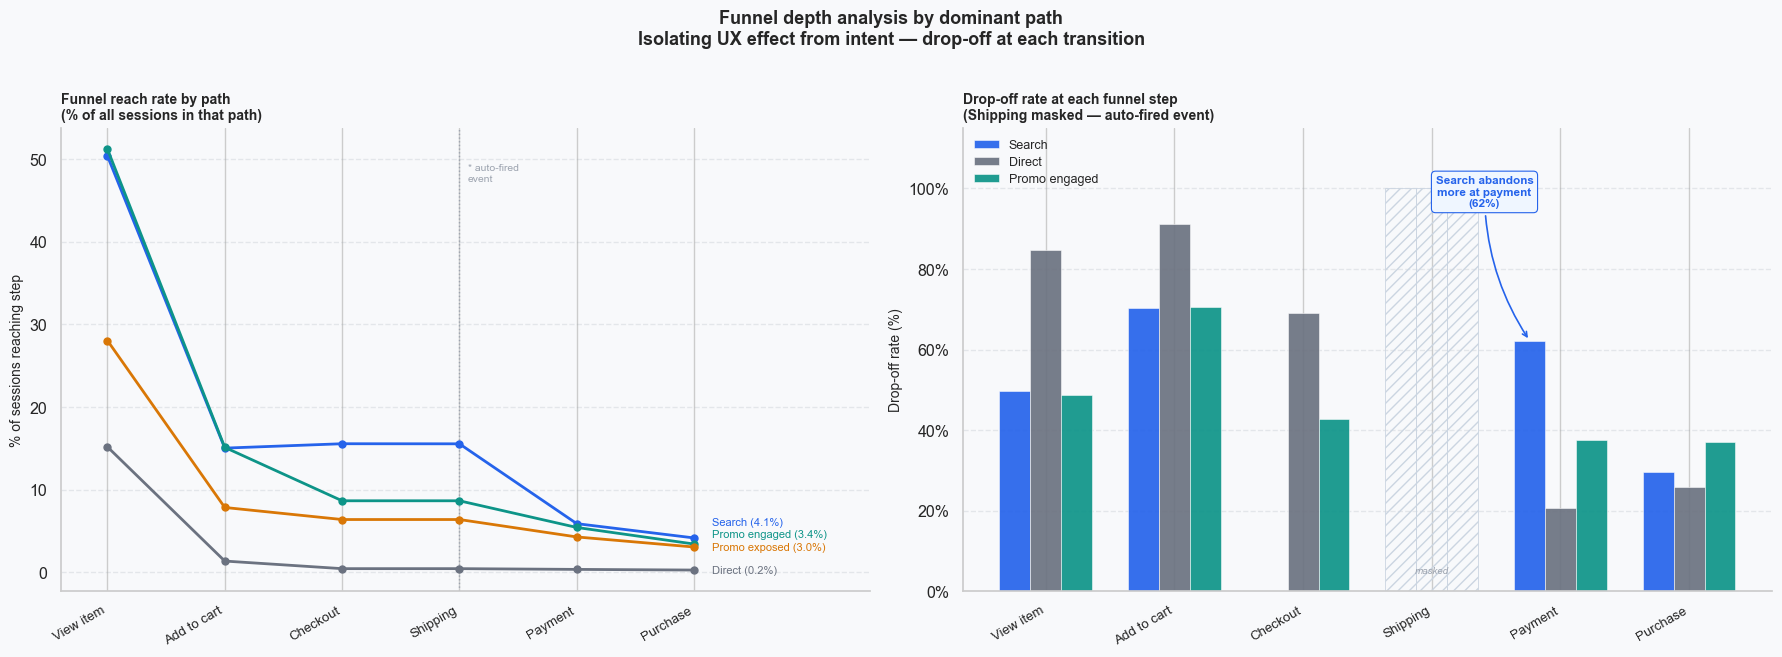

In [146]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

BG = "#F8F9FB"
PATH_COLORS = {
    'search':        '#2563EB',
    'promo_engaged': '#0D9488',
    'promo_exposed': '#D97706',
    'direct':        '#6B7280',
}
PATH_LABELS = {
    'search':        'Search',
    'promo_engaged': 'Promo engaged',
    'promo_exposed': 'Promo exposed',
    'direct':        'Direct',
}
step_order = ['View item', 'Add to cart', 'Checkout',
              'Shipping', 'Payment', 'Purchase']
n_steps = len(step_order)
x       = np.arange(n_steps)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6.5))
fig.patch.set_facecolor(BG)
ax1.set_facecolor(BG)
ax2.set_facecolor(BG)

fig.suptitle(
    'Funnel depth analysis by dominant path\n'
    'Isolating UX effect from intent — drop-off at each transition',
    fontsize=13, fontweight='bold', y=1.01
)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL 1 — Reach rate lines
# ══════════════════════════════════════════════════════════════════════════════
paths_to_plot = ['search', 'promo_engaged', 'promo_exposed', 'direct']

# Collect last values for staggered end-of-line labels
end_labels = []

for path in paths_to_plot:
    data = (df_funnel_depth[df_funnel_depth['path'] == path]
            .set_index('step')
            .reindex(step_order))
    vals = data['reach_rate'].values

    ax1.plot(x, vals,
             marker='o', linewidth=2, markersize=5,
             color=PATH_COLORS[path], label=PATH_LABELS[path],
             zorder=3)

    last_val = vals[-1]
    end_labels.append((last_val, path))

# Sort end labels by value and stagger to avoid overlap
end_labels.sort(key=lambda t: t[0])
used_y = []
MIN_GAP = 1.5   # minimum % gap between labels

for raw_y, path in end_labels:
    # Push label up if too close to an already-placed one
    y_pos = raw_y
    for uy in used_y:
        if abs(y_pos - uy) < MIN_GAP:
            y_pos = uy + MIN_GAP
    used_y.append(y_pos)

    ax1.text(n_steps - 0.85, y_pos,
             f"{PATH_LABELS[path]} ({raw_y:.1f}%)",
             fontsize=8, color=PATH_COLORS[path],
             va='center', ha='left', zorder=5)

ax1.set_title('Funnel reach rate by path\n(% of all sessions in that path)',
              loc='left', fontweight='bold', fontsize=10)
ax1.set_ylabel('% of sessions reaching step', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(step_order, rotation=30, ha='right', fontsize=9.5)
ax1.set_xlim(-0.4, n_steps + 0.5)   # extra right margin for end labels
ax1.yaxis.grid(True, alpha=0.22, linestyle='--', color='#9CA3AF')
ax1.set_axisbelow(True)

# Shipping vertical guide
ax1.axvline(x=3, color='#9CA3AF', linestyle=':', linewidth=1, zorder=1)
ax1.text(3.07, ax1.get_ylim()[1] * 0.92,
         '* auto-fired\nevent',
         fontsize=7.5, color='#9CA3AF', va='top')

sns.despine(ax=ax1)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL 2 — Drop-off grouped bars
# ══════════════════════════════════════════════════════════════════════════════
def get_drop(path):
    s = (df_funnel_depth[df_funnel_depth['path'] == path]
         .set_index('step').reindex(step_order)['drop_rate'].copy())
    s.loc['Shipping'] = np.nan
    return s.values

drop_search = get_drop('search')
drop_direct = get_drop('direct')
drop_promo  = get_drop('promo_engaged')

W = 0.24
ax2.bar(x - W, drop_search, width=W, color='#2563EB',
        label='Search',        edgecolor='white', linewidth=0.4,
        alpha=0.92, zorder=2)
ax2.bar(x,     drop_direct, width=W, color='#6B7280',
        label='Direct',        edgecolor='white', linewidth=0.4,
        alpha=0.92, zorder=2)
ax2.bar(x + W, drop_promo,  width=W, color='#0D9488',
        label='Promo engaged', edgecolor='white', linewidth=0.4,
        alpha=0.92, zorder=2)

# Hatch on masked Shipping column
for offset in [-W, 0, W]:
    ax2.bar(3 + offset, 100, width=W, bottom=0,
            color='none', edgecolor='#CBD5E1',
            linewidth=0.6, hatch='///', zorder=2)

# Shipping label
ax2.text(3, 4, 'masked', ha='center', va='bottom',
         fontsize=7, color='#9CA3AF', style='italic')

# ── Key finding annotation — placed ABOVE the bar, arrow pointing DOWN ────────
pay_idx  = 4          # "Payment" position
bar_top  = 62.22      # approximate bar height for search@payment
ann_y    = 95         # text box y
ann_x    = pay_idx - W - 0.35   # slightly left of the search bar

ax2.annotate(
    'Search abandons\nmore at payment\n(62%)',
    xy=(pay_idx - W, bar_top),          # arrowhead → top of bar
    xytext=(ann_x, ann_y),              # text box above
    fontsize=8.5, color='#2563EB', fontweight='bold',
    ha='center', va='bottom',
    arrowprops=dict(arrowstyle='->', color='#2563EB',
                    lw=1.2, connectionstyle='arc3,rad=0.15'),
    bbox=dict(boxstyle='round,pad=0.35',
              fc='#EFF6FF', ec='#2563EB', lw=0.8),
    zorder=6
)

ax2.set_title('Drop-off rate at each funnel step\n'
              '(Shipping masked — auto-fired event)',
              loc='left', fontweight='bold', fontsize=10)
ax2.set_ylabel('Drop-off rate (%)', fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(step_order, rotation=30, ha='right', fontsize=9.5)
ax2.set_ylim(0, 115)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"{int(v)}%"))
ax2.yaxis.grid(True, alpha=0.22, linestyle='--', color='#9CA3AF')
ax2.set_axisbelow(True)
ax2.legend(frameon=False, fontsize=9, loc='upper left',
           labelspacing=0.4)

sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'funnel_depth_by_path_v3.png',
            dpi=150, bbox_inches='tight')
plt.show()

> **Data artifact — shipping step excluded from friction analysis**
> The `add_shipping_info` event records a 0% drop-off rate across all path
> types. This is consistent with automatic event firing upon page load for
> logged-in Google account holders whose shipping information is
> pre-populated, rather than reflecting a genuine user action.
> This step is excluded from all drop-off comparisons. See Limitation 3
> in the Methodological Limitations section for full details.

In [110]:
# ── Time-to-purchase analysis ─────────────────────────────────────────────────

# Buying sessions only
df_buyers = df_sessions_clean[df_sessions_clean['did_purchase'] == 1].copy()
df_buyers['session_duration_min'] = df_buyers['session_duration_min'].astype(float).fillna(0)

print(f"Total buying sessions : {len(df_buyers):,}")
print(f"\n=== Session duration by path (buyers only) ===")
duration_stats = (df_buyers
    .groupby('dominant_path')['session_duration_min']
    .describe()
    .round(2))
print(duration_stats.to_string())

print(f"\n=== Median duration by path ===")
print(df_buyers.groupby('dominant_path')['session_duration_min']
      .median().round(2))

print(f"\n=== Mean vs Median gap (skewness indicator) ===")
gap = duration_stats[['mean', '50%']].copy()
gap.columns = ['mean', 'median']
gap['mean_median_ratio'] = (gap['mean'] / gap['median']).round(2)
print(gap.to_string())

# ── Speed buckets ─────────────────────────────────────────────────────────────
df_buyers['speed_bucket'] = pd.cut(
    df_buyers['session_duration_min'],
    bins=[-1, 1, 5, 15, 30, 10000],
    labels=['< 1 min', '1–5 min', '5–15 min', '15–30 min', '30+ min']
)

speed_dist = (df_buyers
    .groupby(['dominant_path', 'speed_bucket'], observed=True)
    .size()
    .reset_index(name='count'))

speed_dist['pct'] = (speed_dist
    .groupby('dominant_path')['count']
    .transform(lambda x: x / x.sum() * 100)
    .round(1))

print(f"\n=== Decision speed distribution by path (% of buying sessions) ===")
pivot_speed = speed_dist.pivot(
    index='dominant_path',
    columns='speed_bucket',
    values='pct'
).fillna(0).round(1)
print(pivot_speed.to_string())

Total buying sessions : 4,848

=== Session duration by path (buyers only) ===
                count   mean    std  min   25%   50%   75%    max
dominant_path                                                    
direct          553.0  18.37  17.73  0.0   6.0  13.0  25.0  148.0
promo_engaged   227.0  25.54  19.25  2.0  11.0  20.0  34.0   93.0
promo_exposed  3417.0  23.21  19.48  1.0  10.0  18.0  31.0  189.0
search          651.0  27.43  21.83  1.0  12.0  21.0  38.0  132.0

=== Median duration by path ===
dominant_path
direct           13.0
promo_engaged    20.0
promo_exposed    18.0
search           21.0
Name: session_duration_min, dtype: float64

=== Mean vs Median gap (skewness indicator) ===
                mean  median  mean_median_ratio
dominant_path                                  
direct         18.37    13.0               1.41
promo_engaged  25.54    20.0               1.28
promo_exposed  23.21    18.0               1.29
search         27.43    21.0               1.31

=== Decisi

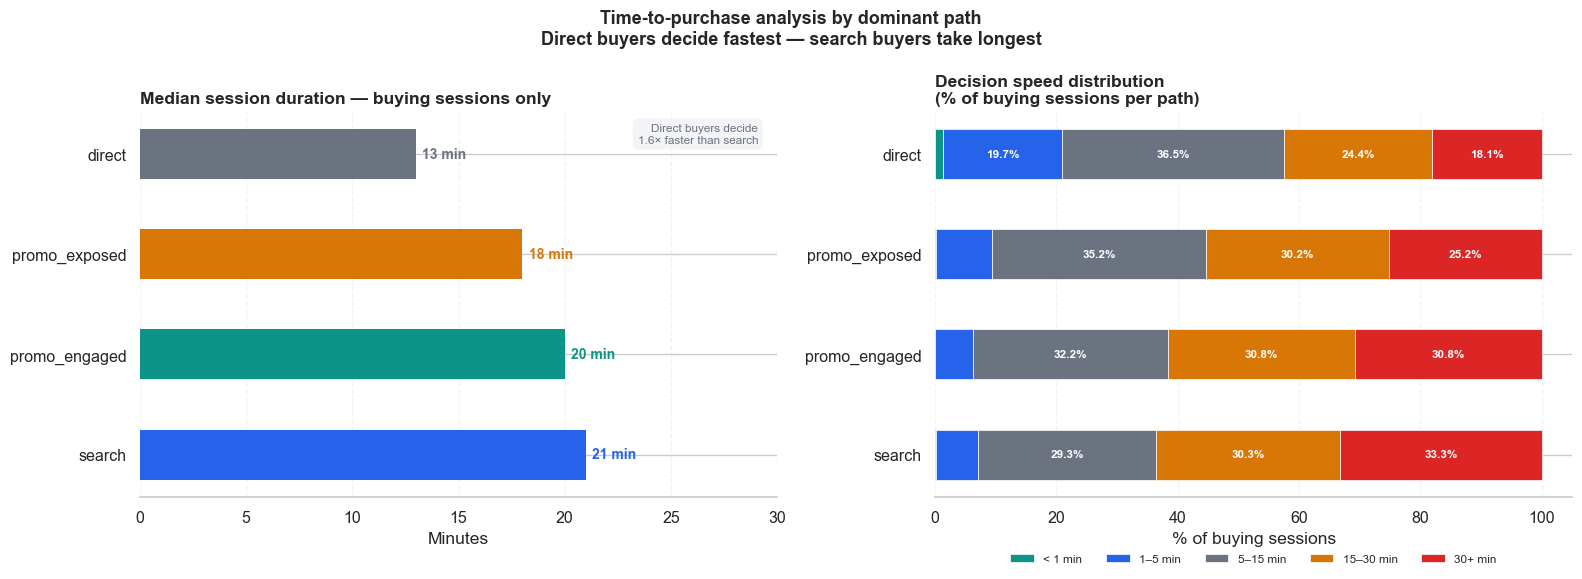

Saved.


In [ ]:
# ── Time-to-purchase visualization v2 ────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Time-to-purchase analysis by dominant path\n'
    'Direct buyers decide fastest — search buyers take longest',
    fontsize=13, fontweight='bold'
)

PATH_COLORS = {
    'search':        '#2563EB',
    'promo_engaged': '#0D9488',
    'promo_exposed': '#D97706',
    'direct':        '#6B7280',
}

path_order = ['direct', 'promo_exposed', 'promo_engaged', 'search']
medians = df_buyers.groupby('dominant_path')['session_duration_min'].median()
medians = medians.reindex(path_order)

# ── Chart 1 — Median session duration ────────────────────────────────────────
bars = ax1.barh(path_order,
                medians.values,
                color=[PATH_COLORS[p] for p in path_order],
                height=0.5, edgecolor='none')

for bar, val in zip(bars, medians.values):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{int(val)} min', va='center', fontsize=10,
             fontweight='bold',
             color=PATH_COLORS[path_order[list(medians.values).index(val)]])

# Annotation moved to top-right corner — no arrow, no overlap risk
ax1.text(0.97, 0.97,
         'Direct buyers decide\n1.6× faster than search',
         transform=ax1.transAxes, ha='right', va='top',
         fontsize=8.5, color='#6B7280',
         bbox=dict(boxstyle='round,pad=0.4', fc='#F3F4F6', ec='none'))

ax1.set_title('Median session duration — buying sessions only',
              loc='left', fontweight='bold')
ax1.set_xlabel('Minutes')
ax1.invert_yaxis()
ax1.set_xlim(0, 30)
ax1.xaxis.grid(True, alpha=0.25, linestyle='--')
ax1.set_axisbelow(True)
sns.despine(ax=ax1, left=True)

# ── Chart 2 — Speed bucket stacked bar ───────────────────────────────────────
bucket_order  = ['< 1 min', '1–5 min', '5–15 min', '15–30 min', '30+ min']
bucket_colors = ['#0D9488', '#2563EB', '#6B7280', '#D97706', '#DC2626']

pivot_speed_plot = speed_dist.pivot(
    index='dominant_path',
    columns='speed_bucket',
    values='pct'
).fillna(0).reindex(path_order)[bucket_order]

bottom = np.zeros(len(path_order))
for bucket, color in zip(bucket_order, bucket_colors):
    vals = pivot_speed_plot[bucket].values
    ax2.barh(path_order, vals, left=bottom,
             color=color, edgecolor='white',
             linewidth=0.5, height=0.5, label=bucket)

    for i, (val, b) in enumerate(zip(vals, bottom)):
        if val >= 10:
            ax2.text(b + val / 2, i,
                     f'{val}%', ha='center', va='center',
                     fontsize=8.5, color='white', fontweight='bold')
    bottom += vals

ax2.set_title('Decision speed distribution\n(% of buying sessions per path)',
              loc='left', fontweight='bold')
ax2.set_xlabel('% of buying sessions')
ax2.set_xlim(0, 105)
ax2.invert_yaxis()

# Legend placed below the chart — no overlap with bars
ax2.legend(frameon=False, fontsize=8.5,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.12),
           ncol=5)

ax2.xaxis.grid(True, alpha=0.25, linestyle='--')
ax2.set_axisbelow(True)
sns.despine(ax=ax2, left=True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "promo_share.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

### Quasi-Experimental Findings

#### Funnel Depth Analysis — Where Does Search Actually Help ?

Examining drop-off rates at each individual funnel transition reveals a more
nuanced picture than aggregate conversion rates suggest.

Search and promo_engaged users enter the funnel at comparable rates — 50.4%
and 51.2% reach the view item stage respectively — suggesting that entry-level
engagement is driven by a shared high-intent profile rather than by the search
feature itself. This partially supports the self-selection hypothesis at the
top of the funnel.

However, the pattern diverges significantly at the add-to-cart transition.
Direct users drop off at 91.1% after viewing an item, compared to 70.2% for
search users and 70.5% for promo_engaged users. This 21-percentage-point gap
at a specific funnel stage is more consistent with a genuine UX effect than
with intent alone — intent affects whether users enter the funnel, friction
affects whether they progress through it. Search appears to help users move
from consideration to action in a way that direct browsing does not.

A notable anomaly emerges at the payment stage : search users abandon at
62.2%, well above direct (20.7%) and promo_engaged (37.4%). Users who reach
payment via search appear more likely to reconsider at the final step,
possibly due to active price comparison behavior enabled by the search feature
itself.

The checkout-to-shipping transition was excluded from friction analysis across
all paths — see Limitation 3.

#### Time-to-Purchase Analysis — Do Search Users Decide Faster ?

Direct path buyers record a median session duration of 13 minutes to purchase,
compared to 21 minutes for search users — a 1.6× difference in the opposite
direction from what a friction-reduction hypothesis would predict. 56.2% of
direct buyers complete their purchase within 15 minutes, versus 36.2% of
search buyers.

Two interpretations are consistent with this finding. First, direct buyers may
represent returning users with strong prior brand familiarity whose speed
reflects pre-existing intent. Second, search may introduce deliberative
behavior — exposing users to a broader product set and enabling comparison —
which extends session duration without constituting friction.

Taken together, these analyses suggest that search contributes a measurable
UX effect at the view item → add to cart transition while simultaneously
enabling deliberative behavior that extends time-to-purchase and increases
late-funnel abandonment. These effects point to a search experience that helps
users find products but may not adequately support final purchase commitment.

# Micro analysis

## Importation via google querry

In [72]:
import sys
!{sys.executable} -m pip install google-cloud-bigquery google-cloud-bigquery-storage pyarrow db-dtypes


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
from google.cloud import bigquery

client = bigquery.Client(project="round-rain-490110-m4")

query = """
    SELECT *
    FROM `round-rain-490110-m4.Dataset_session_level.data-analysis-461114`
"""

df_session = client.query(query).to_dataframe(
    create_bqstorage_client=True
)

In [74]:
from google.cloud import bigquery

client = bigquery.Client(project="round-rain-490110-m4")

query = """
    SELECT *
    FROM `round-rain-490110-m4.data_analysis_user_level.data_analysis_user_level`
"""

df_user = client.query(query).to_dataframe(
    create_bqstorage_client=True
)


In [75]:
print(df_session.dtypes,df_session.shape)


user_pseudo_id           object
session_id                Int64
session_date             dbdate
is_new_user               Int64
medium                   object
source                   object
used_search               Int64
saw_promo                 Int64
clicked_promo             Int64
browsed_list              Int64
selected_item             Int64
did_view_item             Int64
did_add_cart              Int64
did_checkout              Int64
did_shipping              Int64
did_payment               Int64
did_purchase              Int64
session_revenue         float64
unique_events_count       Int64
total_events              Int64
session_duration_min      Int64
dominant_path            object
max_funnel_step           Int64
funnel_stage_label       object
dtype: object (360129, 24)


In [76]:
print(df_user.dtypes,df_user.shape)

user_pseudo_id                object
cohort_month                  dbdate
first_visit_date              dbdate
last_visit_date               dbdate
days_since_last_visit          Int64
total_sessions                 Int64
total_events                   Int64
total_unique_events            Int64
avg_session_duration_min     float64
is_new_user                    Int64
sessions_with_search           Int64
sessions_with_promo            Int64
sessions_with_promo_click      Int64
sessions_with_view_item        Int64
sessions_with_cart             Int64
sessions_with_checkout         Int64
sessions_with_purchase         Int64
recency                        Int64
frequency                      Int64
monetary                     float64
personal_conversion_rate     float64
avg_order_value              float64
dominant_path_overall         object
best_funnel_step               Int64
best_funnel_label             object
dtype: object (287359, 25)


In [77]:
# ── type conversion ──────────────────────────────────────────────────────

# df_session
df_session['session_date'] = pd.to_datetime(df_session['session_date'])

# df_user
date_cols = ['cohort_month', 'first_visit_date', 'last_visit_date']
for col in date_cols:
    df_user[col] = pd.to_datetime(df_user[col])

# ── Missing Value ────────────────────────────────────────────────────────

# avg_order_value : NULL = jamais acheté → 0
df_user['avg_order_value'] = df_user['avg_order_value'].fillna(0)

# session_duration_min : sessions d'un seul event → durée 0
df_session['session_duration_min'] = df_session['session_duration_min'].fillna(0)

# ── Check ──────────────────────────────────────────────────────────────
print("=== df_session ===")
print(f"Time : {df_session['session_date'].min()} → {df_session['session_date'].max()}")
print(f"Missing Value left :\n{df_session.isnull().sum()[df_session.isnull().sum() > 0]}")

print("\n=== df_user ===")
print(f"User with at least 1 buy : {(df_user['frequency'] > 0).sum():,}")
print(f"Users without any buy : {(df_user['frequency'] == 0).sum():,}")
print(f"Missing Value left :\n{df_user.isnull().sum()[df_user.isnull().sum() > 0]}")


=== df_session ===
Time : 2020-11-01 00:00:00 → 2021-01-31 00:00:00
Missing Value left :
Series([], dtype: int64)

=== df_user ===
User with at least 1 buy : 5,463
Users without any buy : 281,896
Missing Value left :
Series([], dtype: int64)


## RFM : finding specific cluster 

In [78]:
print("\n=== RFM describe ===")
print(df_user[['recency', 'frequency', 'monetary']].describe().round(2))



=== RFM describe ===
        recency  frequency   monetary
count  287359.0   287359.0  287359.00
mean      43.99       0.02       1.57
std       25.69       0.16      19.08
min         0.0        0.0       0.00
25%        22.0        0.0       0.00
50%        46.0        0.0       0.00
75%        64.0        0.0       0.00
max        91.0        6.0    1530.00


In [79]:
# ── Distribution cohortes ─────────────────────────────────────────
cohort_counts = (df_user
    .groupby('cohort_month')['user_pseudo_id']
    .count()
    .reset_index()
    .rename(columns={'user_pseudo_id': 'nb_users'}))

print("===Cohort distribution===")
print(cohort_counts.to_string(index=False))

===Cohort distribution===
cohort_month  nb_users
  2020-11-01     86151
  2020-12-01    105585
  2021-01-01     95623


In [80]:
# ── RFM Scoring ──────────────────────────────────────────────────────────────
# Working on all users (including non-buyers — they are valid RFM data points)

df_rfm = df_user[['user_pseudo_id', 'recency', 'frequency', 'monetary']].copy()

# Recency : lower = more recent = better score → reversed order
df_rfm['R'] = pd.qcut(df_rfm['recency'], q=5,
                       labels=[5, 4, 3, 2, 1],
                       duplicates='drop').astype(int)

# Frequency : higher = better score
# Note: 96% of users have frequency=0 → qcut produces degenerate bins
# Using manual thresholds based on actual distribution
df_rfm['F'] = pd.cut(df_rfm['frequency'],
                     bins=[-1, 0, 1, 2, 3, 100],
                     labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary : same issue as Frequency → manual thresholds
df_rfm['M'] = pd.cut(df_rfm['monetary'],
                     bins=[-1, 0, 20, 75, 200, 100000],
                     labels=[1, 2, 3, 4, 5]).astype(int)

# Global RFM score (weighted average — R slightly less weighted)
df_rfm['rfm_score'] = (
    df_rfm['R'] * 0.3 +
    df_rfm['F'] * 0.35 +
    df_rfm['M'] * 0.35
).round(2)

# ── RFM Segmentation ─────────────────────────────────────────────────────────
def rfm_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal customers'
    elif r >= 4 and f <= 2:
        return 'Recent users'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At-risk customers'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost / inactive'
    elif f == 1 and m >= 2:
        return 'Promising'
    else:
        return 'Need attention'

df_rfm['segment'] = df_rfm.apply(rfm_segment, axis=1)

# ── Summary ───────────────────────────────────────────────────────────────────
print("=== RFM Segment Distribution ===")
seg_summary = (df_rfm.groupby('segment')
    .agg(
        nb_users=('user_pseudo_id', 'count'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_monetary=('monetary', 'mean'),
        total_revenue=('monetary', 'sum')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False))

seg_summary['pct_users'] = (
    seg_summary['nb_users'] / len(df_rfm) * 100
).round(1)

seg_summary['pct_revenue'] = (
    seg_summary['total_revenue'] / df_rfm['monetary'].sum() * 100
).round(1)

print(seg_summary.to_string())

=== RFM Segment Distribution ===
                   nb_users  avg_recency  avg_frequency  avg_monetary  total_revenue  pct_users  pct_revenue
segment                                                                                                     
Need attention        63200        46.44           0.05          4.06       256346.0       22.0         56.7
Recent users         115342        17.36           0.01          0.94       108439.0       40.1         24.0
Loyal customers         305        31.03           2.12        196.62        59970.0        0.1         13.3
At-risk customers        96        64.69           2.12        204.62        19644.0        0.0          4.3
Champions                21        13.57           3.33        218.38         4586.0        0.0          1.0
Lost / inactive      108395        70.93            0.0          0.03         3147.0       37.7          0.7


In [81]:
# Check distribution avant de valider les segments
print("=== Frequency distribution ===")
print(df_rfm['frequency'].value_counts().sort_index())

print("\n=== Monetary distribution (buyers only) ===")
print(df_rfm[df_rfm['monetary'] > 0]['monetary'].describe().round(2))

print("\n=== R/F/M scores distribution ===")
for col in ['R', 'F', 'M']:
    print(f"\n{col}:")
    print(df_rfm[col].value_counts().sort_index())

=== Frequency distribution ===
frequency
0    281896
1      5026
2       377
3        47
4        11
6         2
Name: count, dtype: Int64

=== Monetary distribution (buyers only) ===
count    5026.00
mean       89.96
std       113.42
min         1.00
25%        32.00
50%        56.00
75%       100.00
max      1530.00
Name: monetary, dtype: float64

=== R/F/M scores distribution ===

R:
R
1    55474
2    54632
3    61719
4    57550
5    57984
Name: count, dtype: int64

F:
F
1    281896
2      5026
3       377
4        47
5        13
Name: count, dtype: int64

M:
M
1    282333
2       641
3      2421
4      1542
5       422
Name: count, dtype: int64


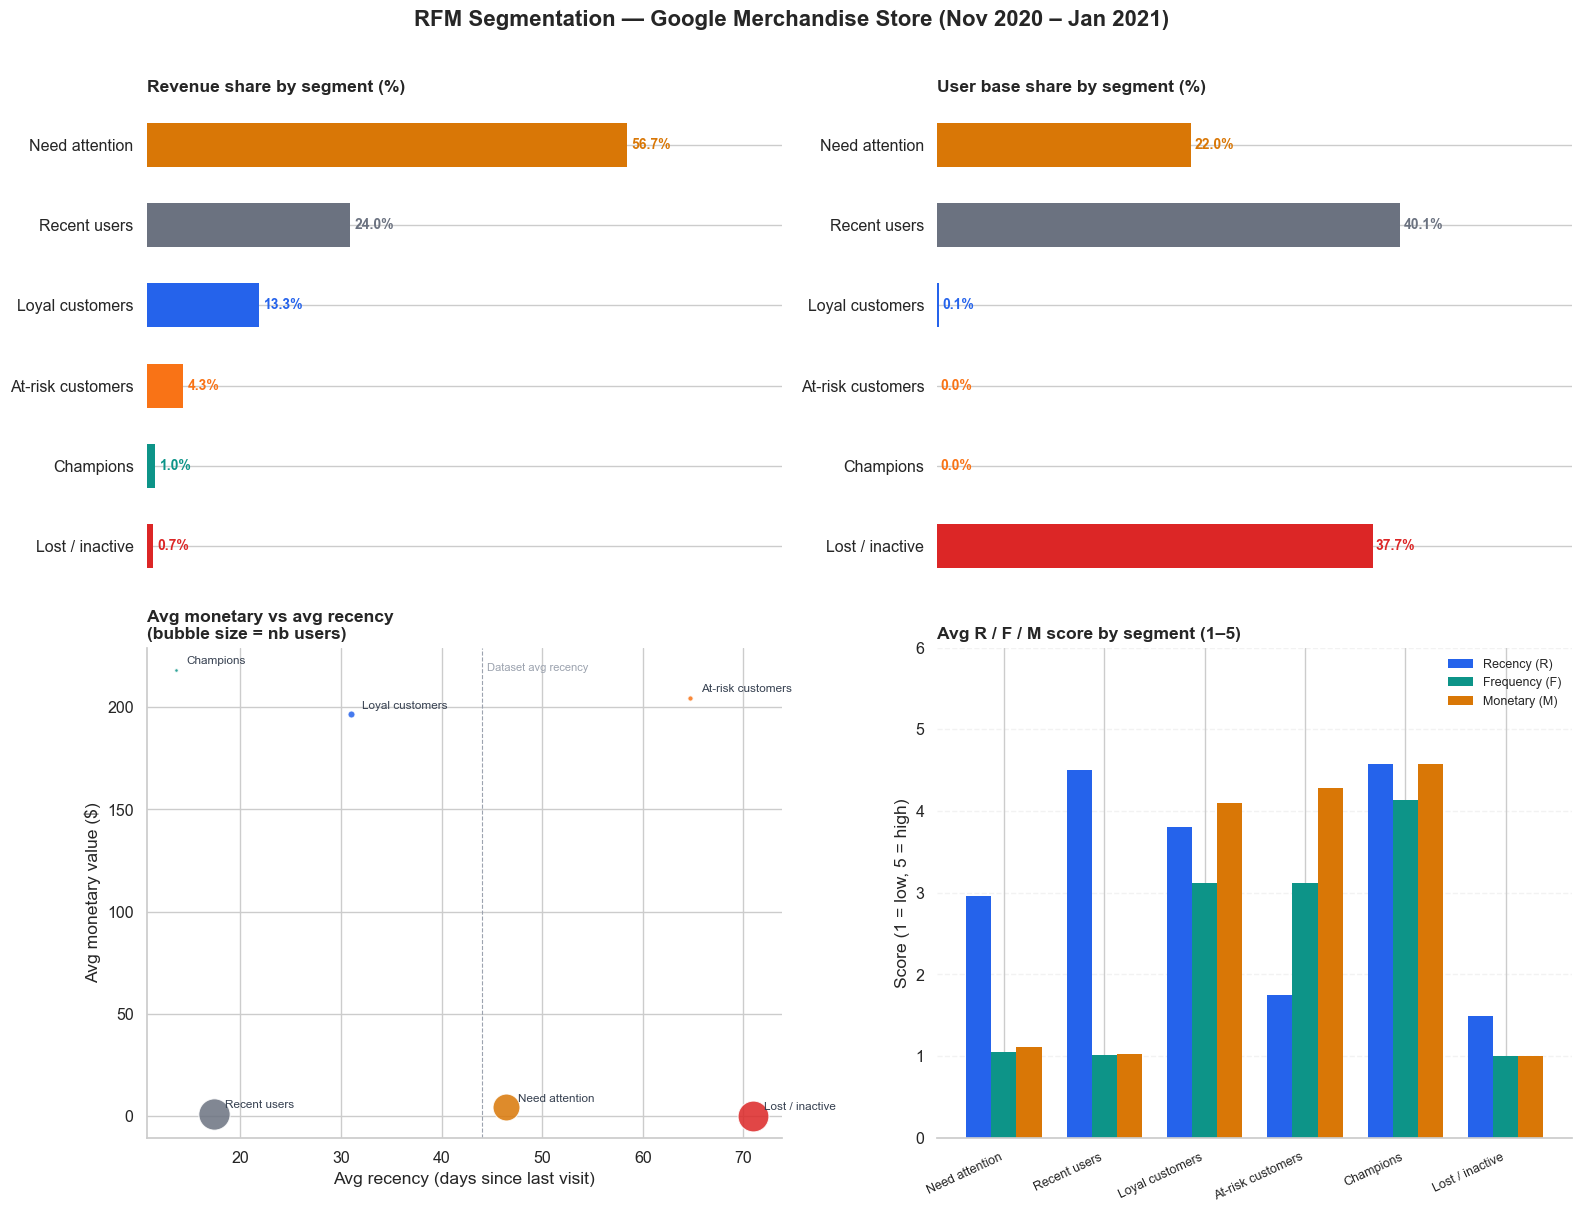

Saved.


In [82]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ── Palette ───────────────────────────────────────────────────────────────────
SEGMENT_COLORS = {
    'Champions':        '#0D9488',
    'Loyal customers':  '#2563EB',
    'Promising':        '#7C3AED',
    'Recent users':     '#6B7280',
    'Need attention':   '#D97706',
    'At-risk customers':'#F97316',
    'Lost / inactive':  '#DC2626',
}

sns.set_theme(style='whitegrid', font_scale=1.05)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('RFM Segmentation — Google Merchandise Store (Nov 2020 – Jan 2021)',
             fontsize=16, fontweight='bold', y=1.01)

seg_plot = seg_summary.reset_index().sort_values('total_revenue', ascending=False)
colors = [SEGMENT_COLORS.get(s, '#999') for s in seg_plot['segment']]

# ── Chart 1 — Revenue share by segment ───────────────────────────────────────
ax1 = axes[0, 0]
bars = ax1.barh(seg_plot['segment'], seg_plot['pct_revenue'],
                color=colors, height=0.55, edgecolor='none')
for bar, val in zip(bars, seg_plot['pct_revenue']):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val}%', va='center', fontsize=10, fontweight='bold',
             color=SEGMENT_COLORS.get(
                 seg_plot.loc[seg_plot['pct_revenue'] == val, 'segment'].values[0], '#333'))
ax1.set_title('Revenue share by segment (%)', loc='left', fontweight='bold')
ax1.set_xlabel('')
ax1.set_xlim(0, 75)
ax1.set_xticks([])
ax1.invert_yaxis()
sns.despine(ax=ax1, left=True, bottom=True)

# ── Chart 2 — User base share by segment ─────────────────────────────────────
ax2 = axes[0, 1]
bars2 = ax2.barh(seg_plot['segment'], seg_plot['pct_users'],
                 color=colors, height=0.55, edgecolor='none')
for bar, val in zip(bars2, seg_plot['pct_users']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val}%', va='center', fontsize=10, fontweight='bold',
             color=SEGMENT_COLORS.get(
                 seg_plot.loc[seg_plot['pct_users'] == val, 'segment'].values[0], '#333'))
ax2.set_title('User base share by segment (%)', loc='left', fontweight='bold')
ax2.set_xlabel('')
ax2.set_xlim(0, 55)
ax2.set_xticks([])
ax2.invert_yaxis()
sns.despine(ax=ax2, left=True, bottom=True)

# ── Chart 3 — Avg monetary vs avg recency (bubble = nb_users) ────────────────
ax3 = axes[1, 0]
for _, row in seg_plot.iterrows():
    size = np.sqrt(row['nb_users']) * 1.5
    ax3.scatter(row['avg_recency'], row['avg_monetary'],
                s=size, color=SEGMENT_COLORS.get(row['segment'], '#999'),
                alpha=0.85, edgecolors='white', linewidth=0.8)
    ax3.annotate(row['segment'],
                 (row['avg_recency'], row['avg_monetary']),
                 textcoords='offset points', xytext=(8, 4),
                 fontsize=8.5, color='#374151')

ax3.set_title('Avg monetary vs avg recency\n(bubble size = nb users)',
              loc='left', fontweight='bold')
ax3.set_xlabel('Avg recency (days since last visit)')
ax3.set_ylabel('Avg monetary value ($)')
ax3.axvline(x=44, color='#9CA3AF', linestyle='--', linewidth=0.8)
ax3.text(44.5, ax3.get_ylim()[1] * 0.95, 'Dataset avg recency',
         fontsize=8, color='#9CA3AF')
sns.despine(ax=ax3)

# ── Chart 4 — R / F / M avg score by segment (radar-style bar) ───────────────
ax4 = axes[1, 1]
rfm_by_seg = (df_rfm.groupby('segment')[['R', 'F', 'M']]
              .mean()
              .round(2)
              .reindex(seg_plot['segment'].tolist()))

x4 = np.arange(len(rfm_by_seg))
w = 0.25
bars_r = ax4.bar(x4 - w, rfm_by_seg['R'], width=w,
                 color='#2563EB', label='Recency (R)', edgecolor='none')
bars_f = ax4.bar(x4,     rfm_by_seg['F'], width=w,
                 color='#0D9488', label='Frequency (F)', edgecolor='none')
bars_m = ax4.bar(x4 + w, rfm_by_seg['M'], width=w,
                 color='#D97706', label='Monetary (M)', edgecolor='none')

ax4.set_xticks(x4)
ax4.set_xticklabels(rfm_by_seg.index, rotation=25, ha='right', fontsize=9)
ax4.set_title('Avg R / F / M score by segment (1–5)',
              loc='left', fontweight='bold')
ax4.set_ylabel('Score (1 = low, 5 = high)')
ax4.set_ylim(0, 6)
ax4.legend(frameon=False, fontsize=9)
ax4.yaxis.grid(True, alpha=0.25, linestyle='--')
ax4.set_axisbelow(True)
sns.despine(ax=ax4, left=True)

plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## K-Mean : Discovering new segment

In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Feature selection ─────────────────────────────────────────────────────────
binary_features = [
    'used_search', 'saw_promo', 'clicked_promo',
    'browsed_list', 'selected_item', 'did_view_item',
    'did_add_cart', 'did_checkout', 'did_purchase'
]

numeric_features = [
    'session_duration_min', 'total_events',
    'session_revenue', 'max_funnel_step'
]

features = binary_features + numeric_features

# ── Data preparation ──────────────────────────────────────────────────────────
df_kmeans = df_session[features].copy()

# Cast Int64 to float — sklearn does not support pandas nullable Int64
df_kmeans = df_kmeans.astype(float)

# Fill any residual NaN with 0
df_kmeans = df_kmeans.fillna(0)

# Standardization — mandatory for K-means (sensitive to feature scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kmeans)

print(f"Feature matrix shape : {X_scaled.shape}")
print(f"Features used : {features}")
print(f"\nStats after scaling (should be ~0 mean, ~1 std) :")
print(pd.DataFrame(X_scaled, columns=features).describe().round(2).loc[['mean', 'std']])

Feature matrix shape : (360129, 13)
Features used : ['used_search', 'saw_promo', 'clicked_promo', 'browsed_list', 'selected_item', 'did_view_item', 'did_add_cart', 'did_checkout', 'did_purchase', 'session_duration_min', 'total_events', 'session_revenue', 'max_funnel_step']

Stats after scaling (should be ~0 mean, ~1 std) :
      used_search  saw_promo  clicked_promo  browsed_list  selected_item  \
mean          0.0       -0.0            0.0           0.0            0.0   
std           1.0        1.0            1.0           1.0            1.0   

      did_view_item  did_add_cart  did_checkout  did_purchase  \
mean           -0.0           0.0          -0.0          -0.0   
std             1.0           1.0           1.0           1.0   

      session_duration_min  total_events  session_revenue  max_funnel_step  
mean                  -0.0           0.0             -0.0              0.0  
std                    1.0           1.0              1.0              1.0  


Computing K-means for k=2 to k=10...
  k=2 | inertia=313,792 | silhouette=0.7839
  k=3 | inertia=264,264 | silhouette=0.5672
  k=4 | inertia=234,810 | silhouette=0.5719
  k=5 | inertia=205,724 | silhouette=0.5889
  k=6 | inertia=175,205 | silhouette=0.5889
  k=7 | inertia=145,937 | silhouette=0.6902
  k=8 | inertia=123,311 | silhouette=0.7145
  k=9 | inertia=102,760 | silhouette=0.7658
  k=10 | inertia=89,587 | silhouette=0.7878


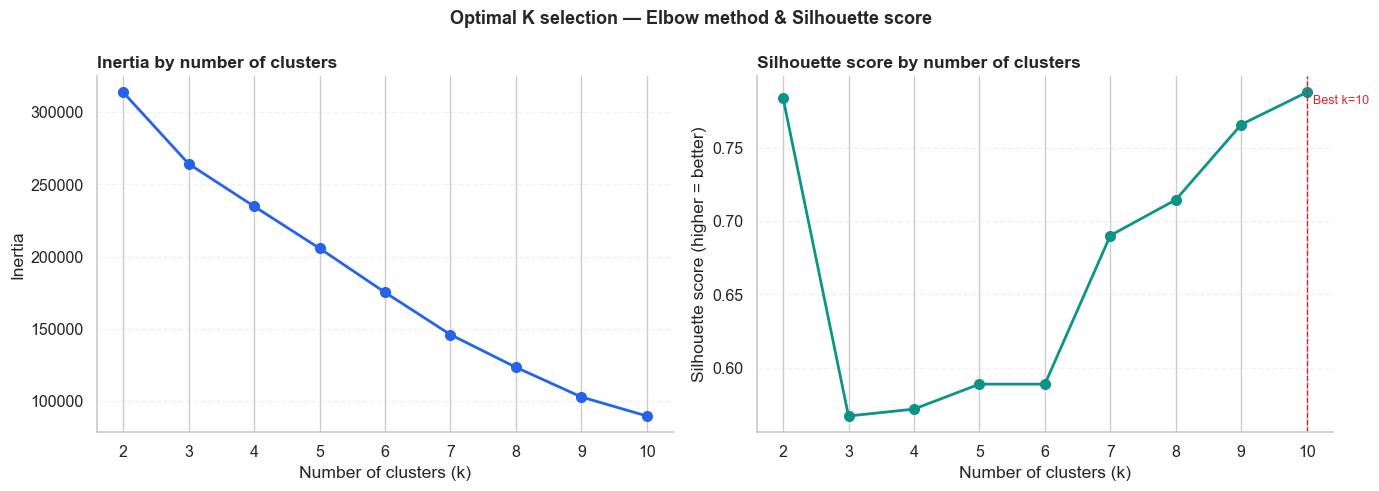


Best k by silhouette : 10
Silhouette scores : [np.float64(0.7839), np.float64(0.5672), np.float64(0.5719), np.float64(0.5889), np.float64(0.5889), np.float64(0.6902), np.float64(0.7145), np.float64(0.7658), np.float64(0.7878)]


In [ ]:
# ── Elbow method + Silhouette score to find optimal K ────────────────────────

# Sample 10% of sessions for faster computation
# Using random_state for reproducibility
SAMPLE_SIZE = 36000
X_sample = pd.DataFrame(X_scaled).sample(
    n=SAMPLE_SIZE, random_state=42
).values

k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("Computing K-means for k=2 to k=10...")
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=10, random_state=42)
    km.fit(X_sample)
    inertias.append(km.inertia_)

    # Silhouette score on a subsample (computationally expensive)
    sil = silhouette_score(X_sample, km.labels_,
                           sample_size=5000, random_state=42)
    silhouette_scores.append(sil)
    print(f"  k={k} | inertia={km.inertia_:,.0f} | silhouette={sil:.4f}")

# ── Plot elbow + silhouette ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal K selection — Elbow method & Silhouette score',
             fontsize=13, fontweight='bold')

# Elbow curve
ax1.plot(list(k_range), inertias, marker='o', color='#2563EB',
         linewidth=2, markersize=7)
ax1.set_title('Inertia by number of clusters', loc='left', fontweight='bold')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.yaxis.grid(True, alpha=0.25, linestyle='--')
ax1.set_axisbelow(True)
sns.despine(ax=ax1)

# Silhouette score
ax2.plot(list(k_range), silhouette_scores, marker='o', color='#0D9488',
         linewidth=2, markersize=7)
ax2.set_title('Silhouette score by number of clusters', loc='left', fontweight='bold')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score (higher = better)')
ax2.yaxis.grid(True, alpha=0.25, linestyle='--')
ax2.set_axisbelow(True)
sns.despine(ax=ax2)

# Highlight best silhouette
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
ax2.axvline(x=best_k, color='#DC2626', linestyle='--', linewidth=1)
ax2.text(best_k + 0.1, max(silhouette_scores) * 0.99,
         f'Best k={best_k}', color='#DC2626', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "promo_share.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest k by silhouette : {best_k}")
print(f"Silhouette scores : {[round(s, 4) for s in silhouette_scores]}")

Computing K-means on RFM raw values (recency / frequency / monetary)...
  k=2 | inertia=500,886 | silhouette=0.8684
  k=3 | inertia=293,811 | silhouette=0.6107
  k=4 | inertia=184,699 | silhouette=0.6135
  k=5 | inertia=141,507 | silhouette=0.5950
  k=6 | inertia=103,479 | silhouette=0.5960
  k=7 | inertia=86,002 | silhouette=0.5974
  k=8 | inertia=73,018 | silhouette=0.5697
  k=9 | inertia=60,178 | silhouette=0.5689
  k=10 | inertia=52,680 | silhouette=0.5711


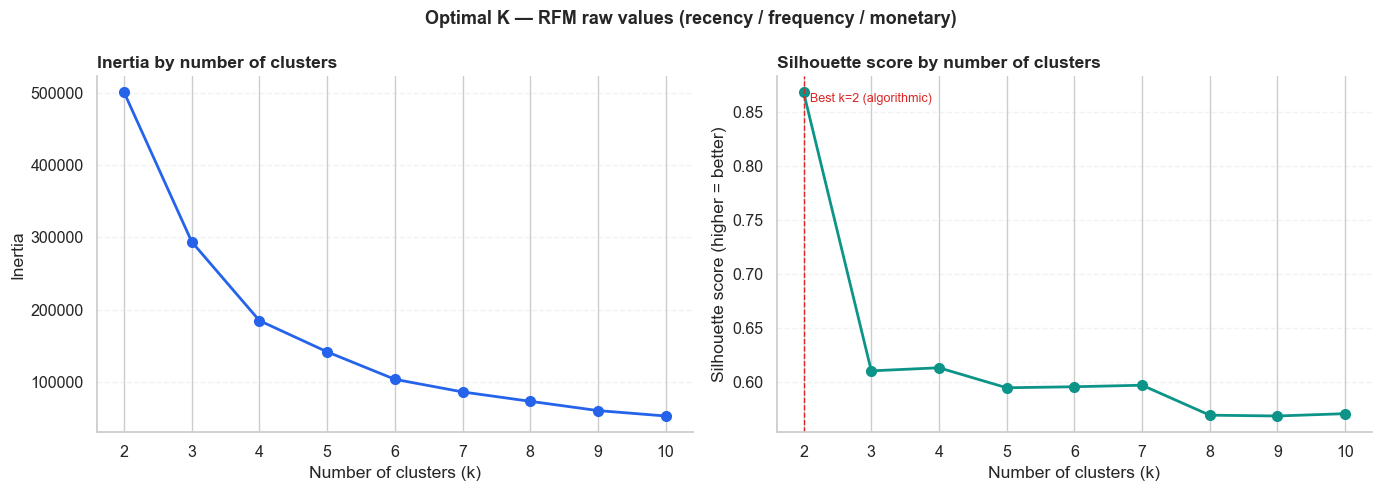


Algorithmic best k : 2
Silhouette scores  : [np.float64(0.8684), np.float64(0.6107), np.float64(0.6135), np.float64(0.595), np.float64(0.596), np.float64(0.5974), np.float64(0.5697), np.float64(0.5689), np.float64(0.5711)]

→ See next cell for business-driven k selection.


In [114]:
# ── K-means on RFM RAW values — évite le biais de discrétisation ─────────────
#
# ⚠️  Pourquoi ne pas utiliser R / F / M (scores discrets 1–5) :
#     K-means sur des entiers 1–5 retombe exactement sur les bins de
#     discrétisation → silhouette artificiellement élevé (~0.99).
#     Ce n'est pas de la segmentation, c'est de la tautologie.
#     On travaille sur recency / frequency / monetary bruts.

X_rfm_raw = df_rfm[['recency', 'frequency', 'monetary']].astype(float).values

scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(X_rfm_raw)

k_range = range(2, 11)
inertias_rfm          = []
silhouette_scores_rfm = []

print("Computing K-means on RFM raw values (recency / frequency / monetary)...")
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_rfm_scaled)
    inertias_rfm.append(km.inertia_)
    sil = silhouette_score(X_rfm_scaled, km.labels_,
                           sample_size=10_000, random_state=42)
    silhouette_scores_rfm.append(sil)
    print(f"  k={k} | inertia={km.inertia_:,.0f} | silhouette={sil:.4f}")

# ── Plot elbow + silhouette ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal K — RFM raw values (recency / frequency / monetary)',
             fontsize=13, fontweight='bold')

ax1.plot(list(k_range), inertias_rfm, marker='o',
         color='#2563EB', linewidth=2, markersize=7)
ax1.set_title('Inertia by number of clusters', loc='left', fontweight='bold')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.yaxis.grid(True, alpha=0.25, linestyle='--')
ax1.set_axisbelow(True)
sns.despine(ax=ax1)

ax2.plot(list(k_range), silhouette_scores_rfm, marker='o',
         color='#0D9488', linewidth=2, markersize=7)
ax2.set_title('Silhouette score by number of clusters', loc='left', fontweight='bold')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score (higher = better)')
ax2.yaxis.grid(True, alpha=0.25, linestyle='--')
ax2.set_axisbelow(True)
sns.despine(ax=ax2)

best_k_rfm = list(k_range)[silhouette_scores_rfm.index(max(silhouette_scores_rfm))]
ax2.axvline(x=best_k_rfm, color='#DC2626', linestyle='--', linewidth=1)
ax2.text(best_k_rfm + 0.1, max(silhouette_scores_rfm) * 0.99,
         f'Best k={best_k_rfm} (algorithmic)', color='#DC2626', fontsize=9)

plt.tight_layout()
plt.savefig('kmeans_rfm_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAlgorithmic best k : {best_k_rfm}")
print(f"Silhouette scores  : {[round(s, 4) for s in silhouette_scores_rfm]}")
print("\n→ See next cell for business-driven k selection.")

In [116]:
# ── Final K-means on RFM space — k=4 selection rationale ────────────────────
#
# Curve readings (cell 39) :
#   - Silhouette : k=2 dominates (~0.86), drops sharply at k=3 (~0.61),
#     then plateaus at low values → the natural structure of the data is
#     binary (buyers vs non-buyers), consistent with 98% of users having
#     frequency=0.
#   - Elbow : continuous descent with no clear inflection point ;
#     slope flattens from k=3 onward, no sharp bend between k=3 and k=5.
#
# Why k=2 is rejected despite the silhouette score :
#   k=2 simply separates buyers from non-buyers, which is equivalent to
#   replicating the `frequency > 0` flag — no additional actionable insight.
#
# Why k=4 :
#   k=4 is a deliberate business-driven override : splitting non-buyers
#   by recency (recent vs lapsed) and buyers by repeat behavior
#   (one-shot vs loyal) yields 4 distinct, CRM-actionable profiles.
#   This is an interpretive choice, not a mechanical reading of the
#   silhouette score.

OPTIMAL_K_RFM = 4

In [117]:
# ── Final K-means on RFM space with k=4 ──────────────────────────────────────

kmeans_rfm = KMeans(
    n_clusters=OPTIMAL_K_RFM,
    init='k-means++',
    n_init=10,
    random_state=42
)
kmeans_rfm.fit(X_rfm_scaled)

# Assign cluster labels to df_rfm
df_rfm['kmeans_cluster'] = kmeans_rfm.labels_

# ── Cluster profiling ─────────────────────────────────────────────────────────
cluster_profile = (df_rfm
    .groupby('kmeans_cluster')
    .agg(
        nb_users=('user_pseudo_id', 'count'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_monetary=('monetary', 'mean'),
        avg_R=('R', 'mean'),
        avg_F=('F', 'mean'),
        avg_M=('M', 'mean'),
        total_revenue=('monetary', 'sum')
    )
    .round(2)
)

cluster_profile['pct_users'] = (
    cluster_profile['nb_users'] / len(df_rfm) * 100
).round(1)

cluster_profile['pct_revenue'] = (
    cluster_profile['total_revenue'] / df_rfm['monetary'].sum() * 100
).round(1)

print("=== K-means RFM cluster profiles ===")
print(cluster_profile.sort_values('avg_monetary', ascending=False).to_string())

# ── Cross-tab : K-means clusters vs RFM rule-based segments ──────────────────
print("\n=== Cross-tab : K-means cluster vs RFM segment ===")
crosstab = pd.crosstab(
    df_rfm['kmeans_cluster'],
    df_rfm['segment'],
    normalize='index'
).round(3) * 100

print(crosstab.to_string())

=== K-means RFM cluster profiles ===
                nb_users  avg_recency  avg_frequency  avg_monetary  avg_R  avg_F  avg_M  total_revenue  pct_users  pct_revenue
kmeans_cluster                                                                                                                
2                    282        45.92           1.56        443.82   2.91   2.55   5.00       125157.0        0.1         27.7
1                   5181        43.09           1.07         63.11   3.06   2.07   3.06       326975.0        1.8         72.3
0                 130181        20.23            0.0          0.00   4.31   1.00   1.00            0.0       45.3          0.0
3                 151715         64.4            0.0          0.00   1.93   1.00   1.00            0.0       52.8          0.0

=== Cross-tab : K-means cluster vs RFM segment ===
segment         At-risk customers  Champions  Lost / inactive  Loyal customers  Need attention  Recent users
kmeans_cluster                          

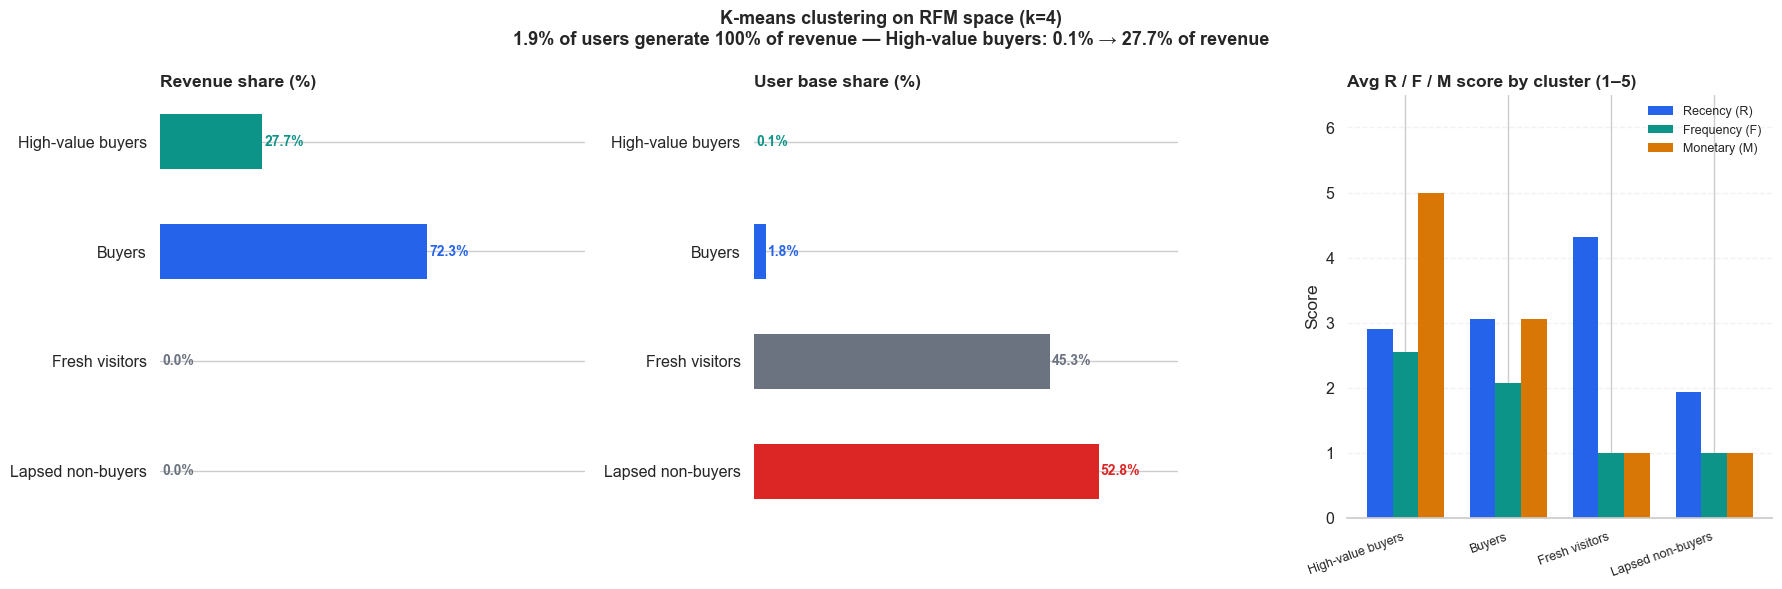

Saved.


In [120]:
# ── Cluster naming based on profiles ─────────────────────────────────────────
#
# Cluster profiles (from cell 40 output) :
#
#   Cluster 2 — 0.1% of users, 27.7% of revenue
#     avg_frequency=1.56, avg_monetary=443, M=5 → high-value repeat buyers
#     → "High-value buyers"
#
#   Cluster 1 — 1.8% of users, 72.3% of revenue
#     avg_frequency=1.07, avg_monetary=63, M=3 → standard one-shot buyers
#     → "Buyers"
#
#   Cluster 0 — 45.3% of users, 0% revenue
#     avg_recency=20 days, frequency=0, R=4.3 → recently acquired, never bought
#     → "Fresh visitors"
#
#   Cluster 3 — 52.8% of users, 0% revenue
#     avg_recency=64 days, frequency=0, R=1.9 → old acquisition, never bought
#     → "Lapsed non-buyers"
#
# Key finding :
#   1.9% of users (clusters 1+2) generate 100% of revenue.
#   The remaining 98.1% have never purchased — split evenly between
#   recently acquired (Fresh visitors) and disengaged (Lapsed non-buyers).
#   High-value buyers (cluster 2) represent only 0.1% of the base
#   but contribute 27.7% of total revenue — a critical retention target.

cluster_names = {
    2: 'High-value buyers',
    1: 'Buyers',
    0: 'Fresh visitors',
    3: 'Lapsed non-buyers'
}

df_rfm['cluster_label'] = df_rfm['kmeans_cluster'].map(cluster_names)

# ── Visualization : 3 charts ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('K-means clustering on RFM space (k=4)\n'
             '1.9% of users generate 100% of revenue — High-value buyers: 0.1% → 27.7% of revenue',
             fontsize=13, fontweight='bold')

CLUSTER_COLORS = {
    'High-value buyers': '#0D9488',
    'Buyers':            '#2563EB',
    'Fresh visitors':    '#6B7280',
    'Lapsed non-buyers': '#DC2626',
}

cluster_plot = (cluster_profile
    .reset_index()
    .assign(label=lambda x: x['kmeans_cluster'].map(cluster_names))
    .sort_values('avg_monetary', ascending=False))

colors_c = [CLUSTER_COLORS[l] for l in cluster_plot['label']]

# Chart 1 — Revenue share
ax1 = axes[0]
bars1 = ax1.barh(cluster_plot['label'], cluster_plot['pct_revenue'],
                 color=colors_c, height=0.5, edgecolor='none')
for bar, val in zip(bars1, cluster_plot['pct_revenue']):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val}%', va='center', fontsize=10, fontweight='bold',
             color=CLUSTER_COLORS[cluster_plot.loc[
                 cluster_plot['pct_revenue'] == val, 'label'].values[0]])
ax1.set_title('Revenue share (%)', loc='left', fontweight='bold')
ax1.set_xlim(0, 115)
ax1.set_xticks([])
ax1.invert_yaxis()
sns.despine(ax=ax1, left=True, bottom=True)

# Chart 2 — User share
ax2 = axes[1]
bars2 = ax2.barh(cluster_plot['label'], cluster_plot['pct_users'],
                 color=colors_c, height=0.5, edgecolor='none')
for bar, val in zip(bars2, cluster_plot['pct_users']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val}%', va='center', fontsize=10, fontweight='bold',
             color=CLUSTER_COLORS[cluster_plot.loc[
                 cluster_plot['pct_users'] == val, 'label'].values[0]])
ax2.set_title('User base share (%)', loc='left', fontweight='bold')
ax2.set_xlim(0, 65)
ax2.set_xticks([])
ax2.invert_yaxis()
sns.despine(ax=ax2, left=True, bottom=True)

# Chart 3 — Avg R / F / M scores per cluster
ax3 = axes[2]
x3 = np.arange(len(cluster_plot))
w = 0.25

ax3.bar(x3 - w, cluster_plot['avg_R'], width=w,
        color='#2563EB', label='Recency (R)', edgecolor='none')
ax3.bar(x3,     cluster_plot['avg_F'], width=w,
        color='#0D9488', label='Frequency (F)', edgecolor='none')
ax3.bar(x3 + w, cluster_plot['avg_M'], width=w,
        color='#D97706', label='Monetary (M)', edgecolor='none')

ax3.set_xticks(x3)
ax3.set_xticklabels(cluster_plot['label'], rotation=20, ha='right', fontsize=9)
ax3.set_title('Avg R / F / M score by cluster (1–5)',
              loc='left', fontweight='bold')
ax3.set_ylabel('Score')
ax3.set_ylim(0, 6.5)
ax3.legend(frameon=False, fontsize=9)
ax3.yaxis.grid(True, alpha=0.25, linestyle='--')
ax3.set_axisbelow(True)
sns.despine(ax=ax3, left=True)

plt.tight_layout()
plt.savefig('kmeans_rfm_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

=== Weekly retention matrix (% of cohort returning) ===
                 W+0   W+1  W+2  W+3  W+4  W+5  W+6  W+7  W+8  W+9  W+10  W+11  W+12
cohort_week                                                                         
Week 26 oct.   100.0  10.7  3.5  2.4  1.4  1.0  0.9  0.3  0.6  0.2   0.4   0.3   0.3
Week 02 nov.   100.0   6.3  3.4  2.4  2.3  2.0  1.3  0.6  0.4  0.7   0.5   0.4   0.4
Week 09 nov.   100.0   6.7  3.1  2.6  2.5  1.5  0.8  0.4  0.6  0.5   0.5   0.4   NaN
Week 16 nov.   100.0   5.8  3.3  2.4  1.8  0.7  0.4  0.5  0.5  0.4   0.4   NaN   NaN
Week 23 nov.   100.0   5.1  2.7  1.6  0.8  0.5  0.5  0.5  0.4  0.5   NaN   NaN   NaN
Week 30 nov.   100.0   5.4  2.2  0.9  0.6  0.7  0.5  0.4  0.4  NaN   NaN   NaN   NaN
Week 07 déc.   100.0   3.3  0.9  0.7  1.0  0.6  0.4  0.4  NaN  NaN   NaN   NaN   NaN
Week 14 déc.   100.0   2.9  0.9  1.3  0.9  0.6  0.5  NaN  NaN  NaN   NaN   NaN   NaN
Week 21 déc.   100.0   2.6  1.2  1.0  0.6  0.4  NaN  NaN  NaN  NaN   NaN   NaN   NaN
Week 28 d

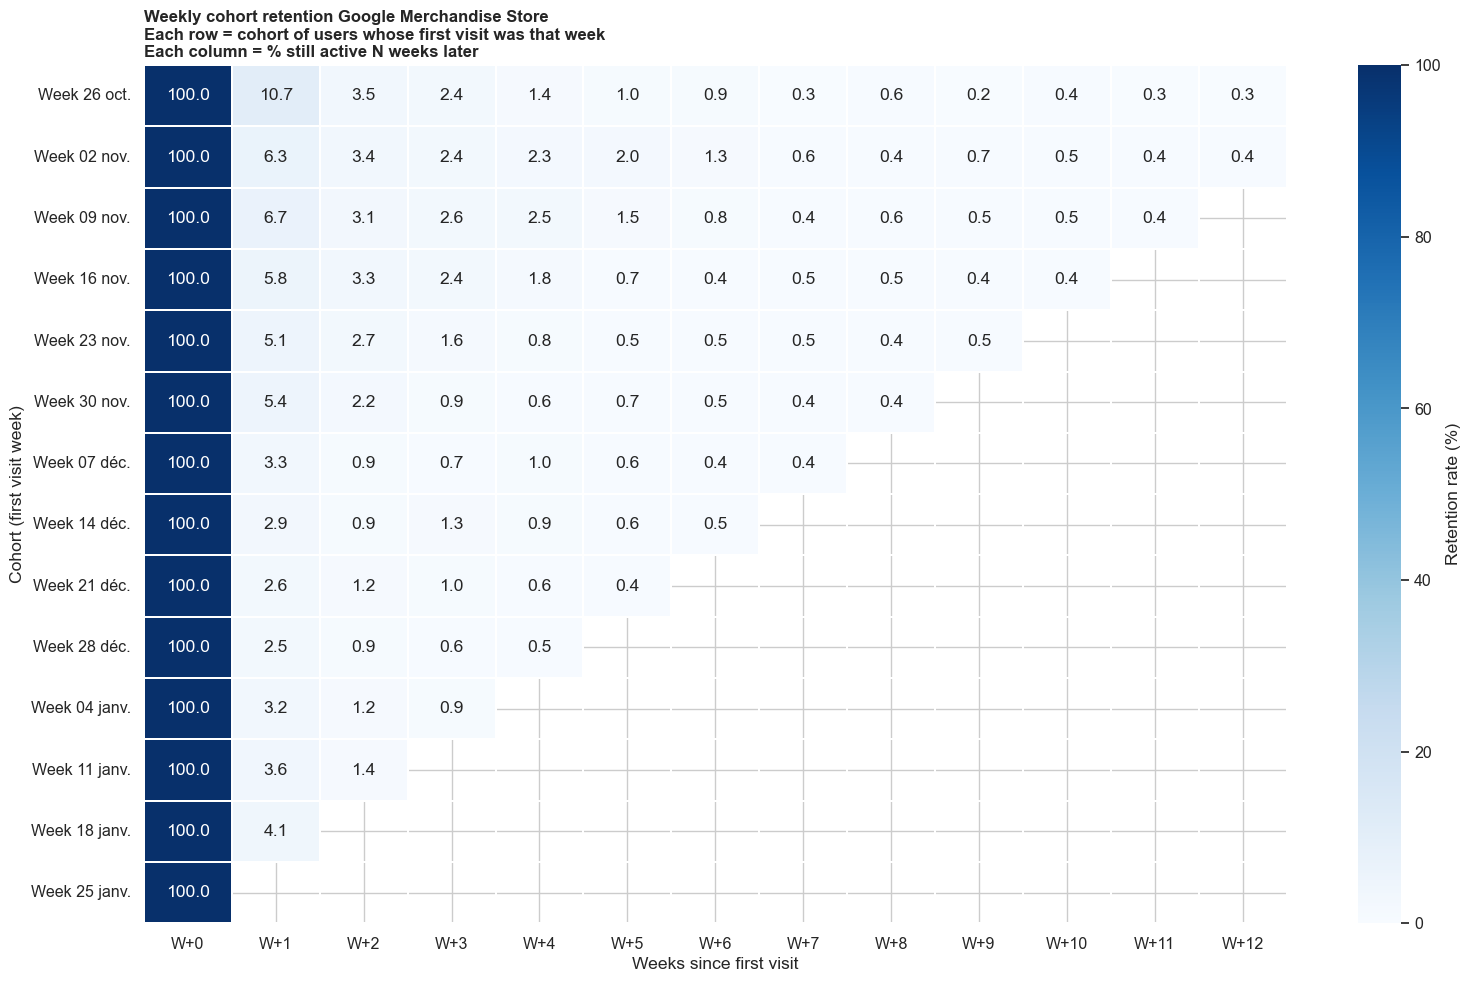

Saved.


In [95]:
# ── Weekly cohort retention analysis ─────────────────────────────────────────

# Build session-level cohort data from df_sessions
# We need first visit week per user + all subsequent session weeks

df_session['session_week'] = pd.to_datetime(
    df_session['session_date']
).dt.to_period('W').dt.start_time

# First session week per user = cohort week
user_cohort_week = (df_session
    .groupby('user_pseudo_id')['session_week']
    .min()
    .reset_index()
    .rename(columns={'session_week': 'cohort_week'})
)

# Merge cohort week back to sessions
df_sessions_cohort = df_session.merge(user_cohort_week, on='user_pseudo_id')

# Compute week offset (0 = cohort week, 1 = week after, etc.)
df_sessions_cohort['week_offset'] = (
    (df_sessions_cohort['session_week'] -
     df_sessions_cohort['cohort_week']).dt.days // 7
)

# ── Build retention matrix ────────────────────────────────────────────────────
# Count distinct users active per cohort week × week offset
retention_raw = (df_sessions_cohort
    .groupby(['cohort_week', 'week_offset'])['user_pseudo_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_pseudo_id': 'active_users'})
)

# Cohort sizes (week offset = 0)
cohort_sizes = (retention_raw[retention_raw['week_offset'] == 0]
    .set_index('cohort_week')['active_users']
    .rename('cohort_size')
)

# Merge cohort size and compute retention rate
retention_raw = retention_raw.merge(cohort_sizes, on='cohort_week')
retention_raw['retention_rate'] = (
    retention_raw['active_users'] / retention_raw['cohort_size'] * 100
).round(1)

# Pivot to heatmap matrix — keep first 12 weeks of offset only
retention_matrix = retention_raw[retention_raw['week_offset'] <= 12].pivot(
    index='cohort_week',
    columns='week_offset',
    values='retention_rate'
)

retention_matrix.columns = [f'W+{c}' for c in retention_matrix.columns]
retention_matrix.index = retention_matrix.index.strftime('Week %d %b')

print("=== Weekly retention matrix (% of cohort returning) ===")
print(retention_matrix.round(1).to_string())

# ── Heatmap visualization ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=100,
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention rate (%)'}
)

ax.set_title(
    'Weekly cohort retention Google Merchandise Store\n'
    'Each row = cohort of users whose first visit was that week\n'
    'Each column = % still active N weeks later',
    loc='left', fontweight='bold', fontsize=12
)
ax.set_xlabel('Weeks since first visit')
ax.set_ylabel('Cohort (first visit week)')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('cohort_retention_weekly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## Summary & Recommendations

Key findings from this analysis are synthesised and prioritised
in the accompanying non-technical presentation.

This notebook documents the full analytical methodology,
data pipeline, and statistical limitations underlying those recommendations.